# Итоговое задание

**Traffic Prediction**

Датасет: https://github.com/MVRonkin/TimeSeriesCourse/blob/fd0f3aeec3bfe81887226bc668e4e1a7cefb0dd2/OLD%20Versions/2026/datasets/Traffic%20Prediction/traffic-prediction-custom-gru-lstm-cnn-mlp.ipynb$0

## EDA

### Подготовка датасета

In [17]:
# установка необходимых библиотек

# базовые
import os
import numpy as np
import pandas as pd

# визуализация
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# для EDA
from pandas.tseries.holiday import USFederalHolidayCalendar
!pip install statsforecast==1.6.0
!pip install statsforecast utilsforecast
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

# для статистических методов
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, ARIMA, Theta, AutoTheta, HoltWinters, ETS
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# для ML
import torch
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
!pip install mlforecast
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

# для DL
!pip install neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, TFT
from neuralforecast.losses.pytorch import MAE, MSE

import warnings
warnings.filterwarnings('ignore')

In [18]:
#загрузка данных
df = pd.read_csv('https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/fd0f3aeec3bfe81887226bc668e4e1a7cefb0dd2/OLD%20Versions/2026/datasets/Traffic%20Prediction/traffic.csv')

In [19]:
# информация о датасете
print('Описание датасета')
print()
print(df.head(5))
print('-'*20)
print()
print(df.info())
print('-'*20)
print()
print('Статистика')
print(df.describe())
print('-'*20)
print()
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
print()
print('-'*20)
print(f'Названия колонок: {df.columns.tolist()}')
print('-'*20)
print()
# Проверка на пропуски
print(f"Пропуски:\n\n{df.isnull().sum()}")
print('-'*20)
print(f'Монтонность: {df.index.is_monotonic_increasing}')
print(f'Дубликаты: {df.index.has_duplicates}')
print('-'*20)
print()
print(f'Примеры строк:\n\n{df.sample(5, random_state=0)}')

Описание датасета

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
--------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
--------------------

Статистика
           Junction      Vehicles            ID
count  48120.000000  48120.000000  4.812000e+04
mean       2.180549     22.791334  2.016330e+10
std        0.966955     20.750063  5.944854e+06
min    

In [20]:
# Удаляем колонку ID
df.drop('ID', axis=1, inplace=True)

In [21]:
# устанавливаем новый индекс в формате DateTime
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
print(f'Тип нового индекса: {type(df.index)}')

Тип нового индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [22]:
# Общая статистика
print(f"Период данных: с {df.index.min()} по {df.index.max()}")
print(f"Частота данных: {df.index.inferred_freq}")

print(f"Всего перекрёстков: {df['Junction'].nunique()}")
print(f"Список перекрёстков: {sorted(df['Junction'].unique())}")

print("\nЗаписей на каждом перекрёстке:")
print(df['Junction'].value_counts().sort_index())

print("\nСреднее количество машин на перекрёстке:")
print(df.groupby('Junction')['Vehicles'].mean().round(2))

Период данных: с 2015-11-01 00:00:00 по 2017-06-30 23:00:00
Частота данных: None
Всего перекрёстков: 4
Список перекрёстков: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Записей на каждом перекрёстке:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

Среднее количество машин на перекрёстке:
Junction
1    45.05
2    14.25
3    13.69
4     7.25
Name: Vehicles, dtype: float64


In [23]:
# проверка регулярности шагов
df = df.sort_index()
dt = df.index.to_series().diff().value_counts()
print(dt.head())

DateTime
0 days 00:00:00    33528
0 days 01:00:00    14591
Name: count, dtype: int64


**Основные характеристики ВР**

- В датасете представлены данные о количестве машин на 4 перекрестах. Замеры идут каждый час. Для 3 перекрестков - длительность временного ряда/количество календарных дней: 608, для четвертого: 181 день.
- Пропусков нет, шаги идут регулярно.

### Визуализация временного ряда

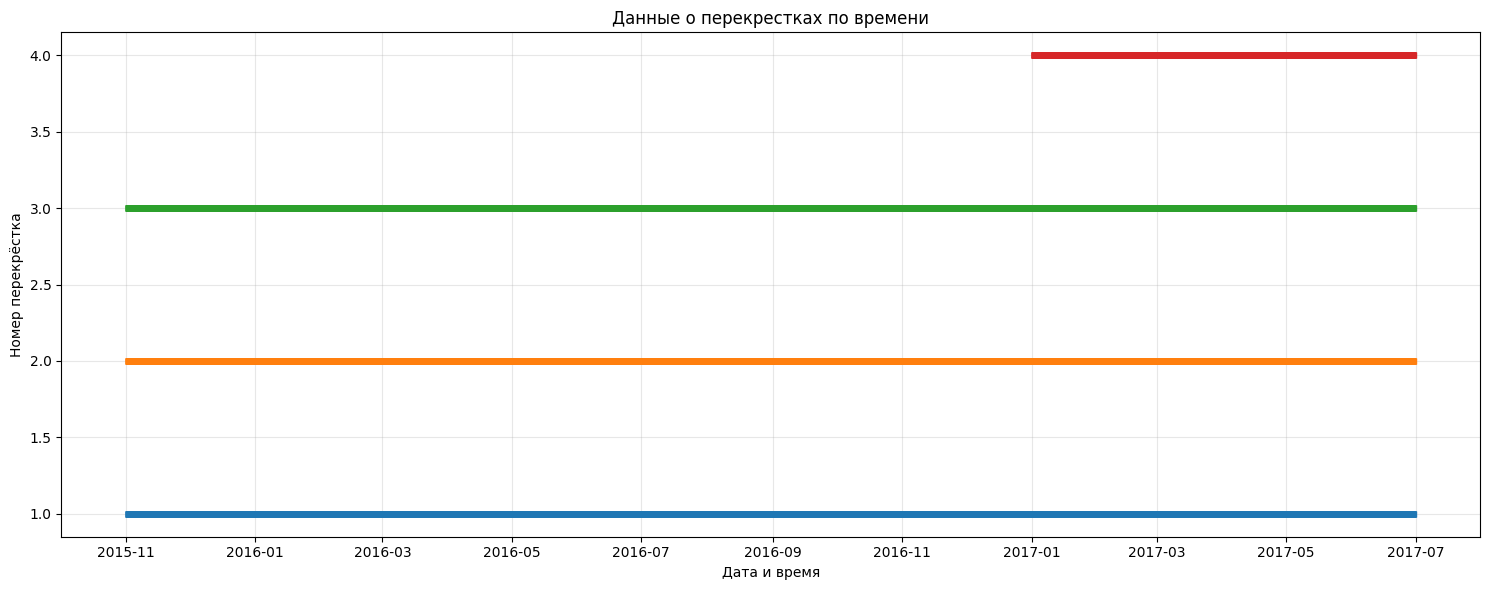

In [8]:
plt.figure(figsize=(15, 6))
df_sorted = df.sort_index()
for junction in df_sorted['Junction'].unique():
    data = df_sorted[df_sorted['Junction'] == junction]
    plt.plot(data.index, [junction] * len(data), '|', markersize=5, label=f'Junction {junction}')

plt.title('Данные о перекрестках по времени')
plt.ylabel('Номер перекрёстка')
plt.xlabel('Дата и время')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

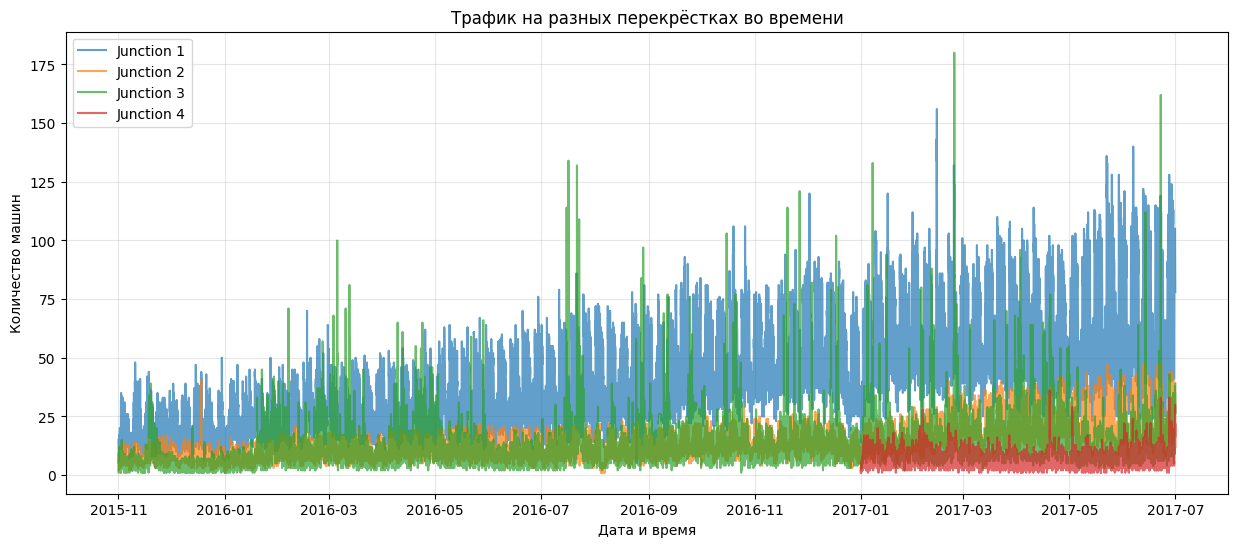

In [9]:
# Графики вместе
plt.figure(figsize=(15, 6))

for junction in df['Junction'].unique():
    data = df[df['Junction'] == junction]
    plt.plot(data.index, data['Vehicles'], label=f'Junction {junction}', alpha=0.7)

plt.title('Трафик на разных перекрёстках во времени')
plt.xlabel('Дата и время')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

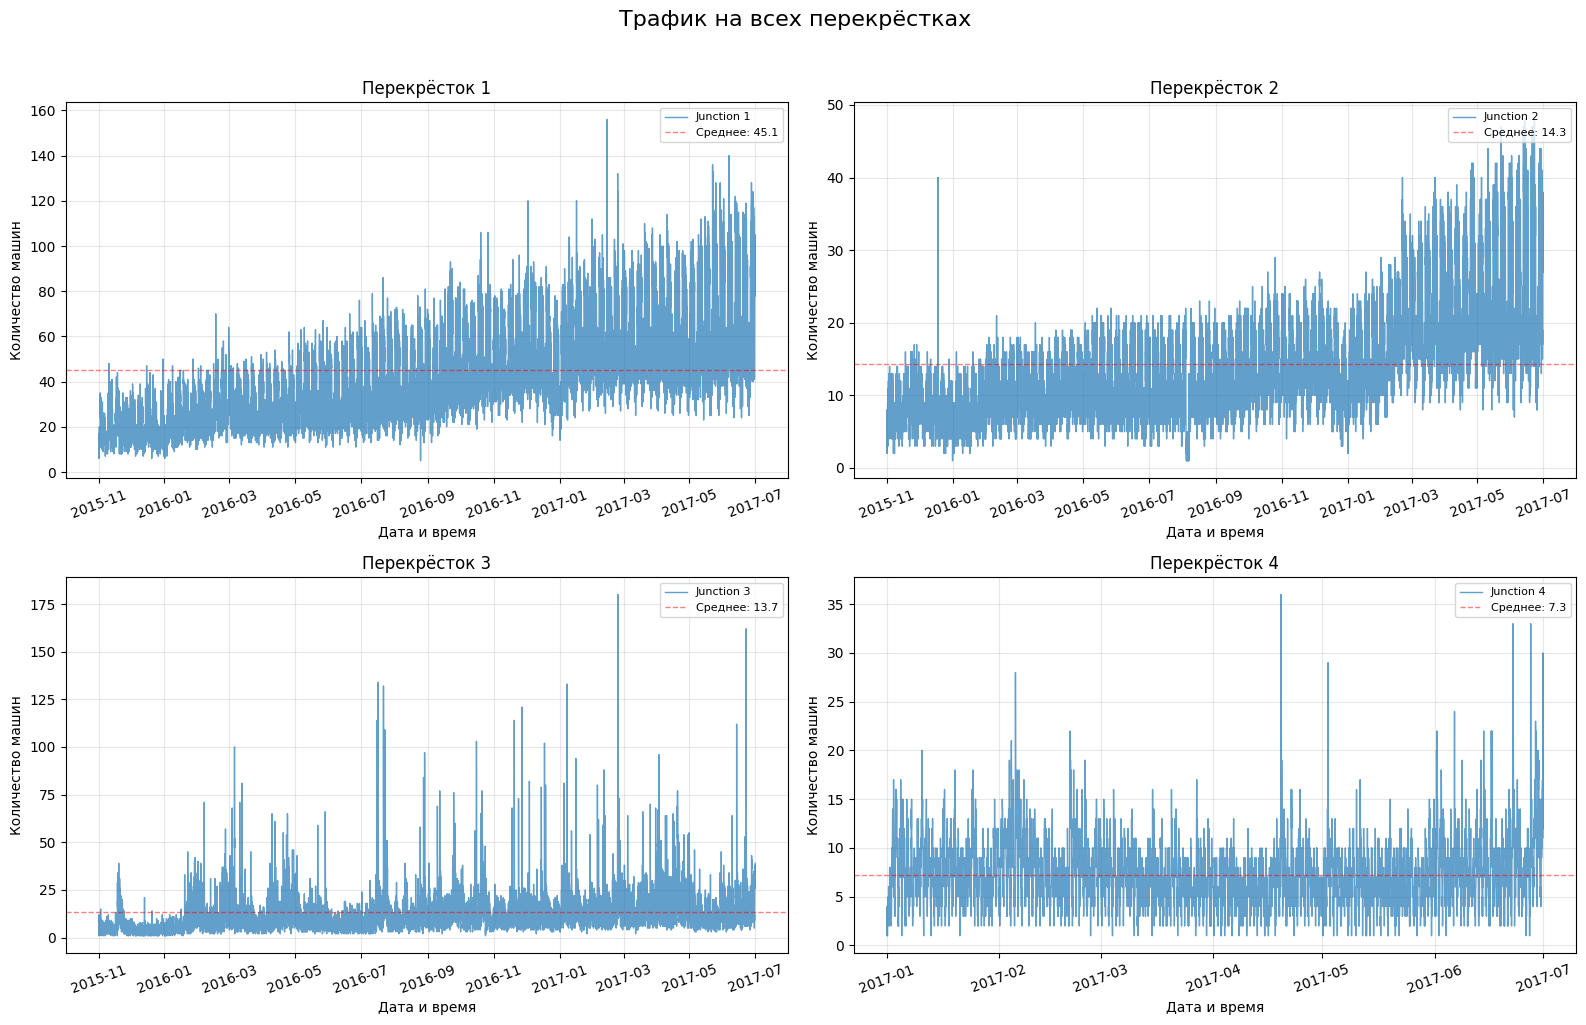

In [10]:
# графики раздельно
junctions = sorted(df['Junction'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 5 * 2))
axes = axes.flatten()

for i, junction in enumerate(junctions):
    data = df[df['Junction'] == junction]

    axes[i].plot(data.index, data['Vehicles'], linewidth=1, alpha=0.7, label=f'Junction {junction}')

    mean_val = data['Vehicles'].mean()
    axes[i].axhline(y=mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Среднее: {mean_val:.1f}')

    axes[i].set_title(f'Перекрёсток {junction}', fontsize=12)
    axes[i].set_xlabel('Дата и время')
    axes[i].set_ylabel('Количество машин')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Трафик на всех перекрёстках', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Визуальная оценка ВР**
- На перекрестках различный трафик
- На 1 тренд растет. Возможно, это транспортное направление становится более популярным. Сравнительно с тремя другими он намного более популярный - в среднем 45,1 машина в час.
- На 2 тренд также растет, но перекресток примерно в три раза менее загружен (в среднем 14,3 машины).
- На 3 перекрестке загруженность близка ко 2 (среднее: 13.7), но нет восходящего тренда. При этом весьма ощутимы выбросы: в 2-3 раза больше среднего количества машин.
- На 4 перекрестке в среднем зафиксировано 7,3 машины. Восходящего тренда нет. Заметны выбросы.

Все 4 ВР необходимо оценивать отдельно.

### Ресеплируем по неделям и месяцам + посмотрим празники и выходные

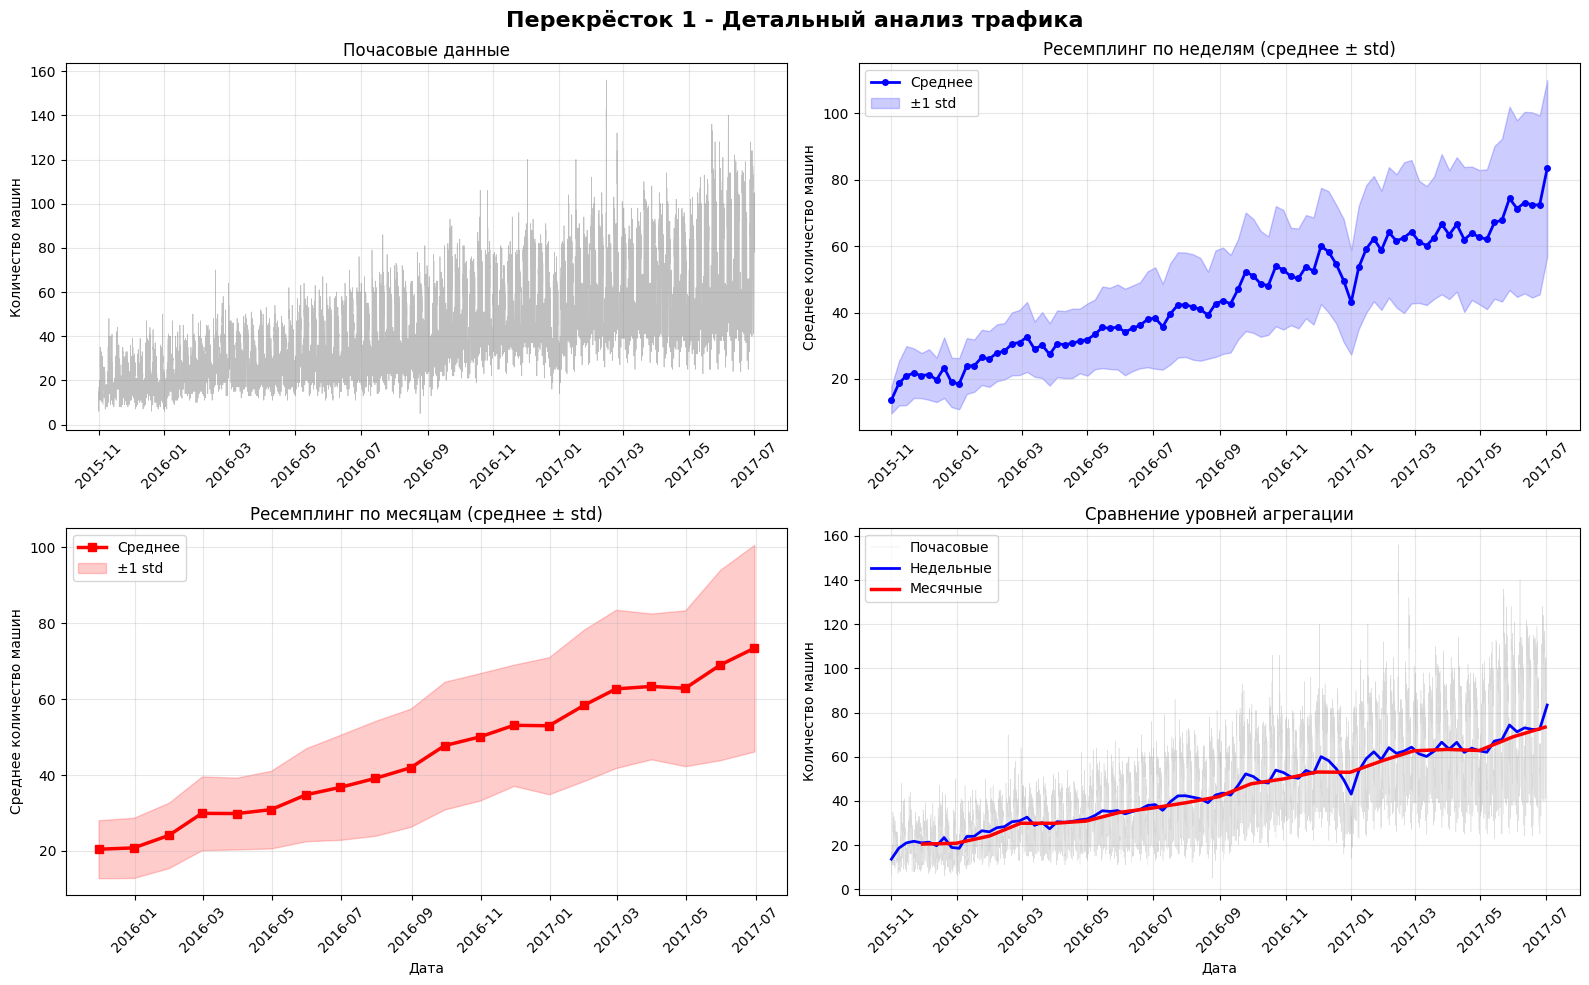

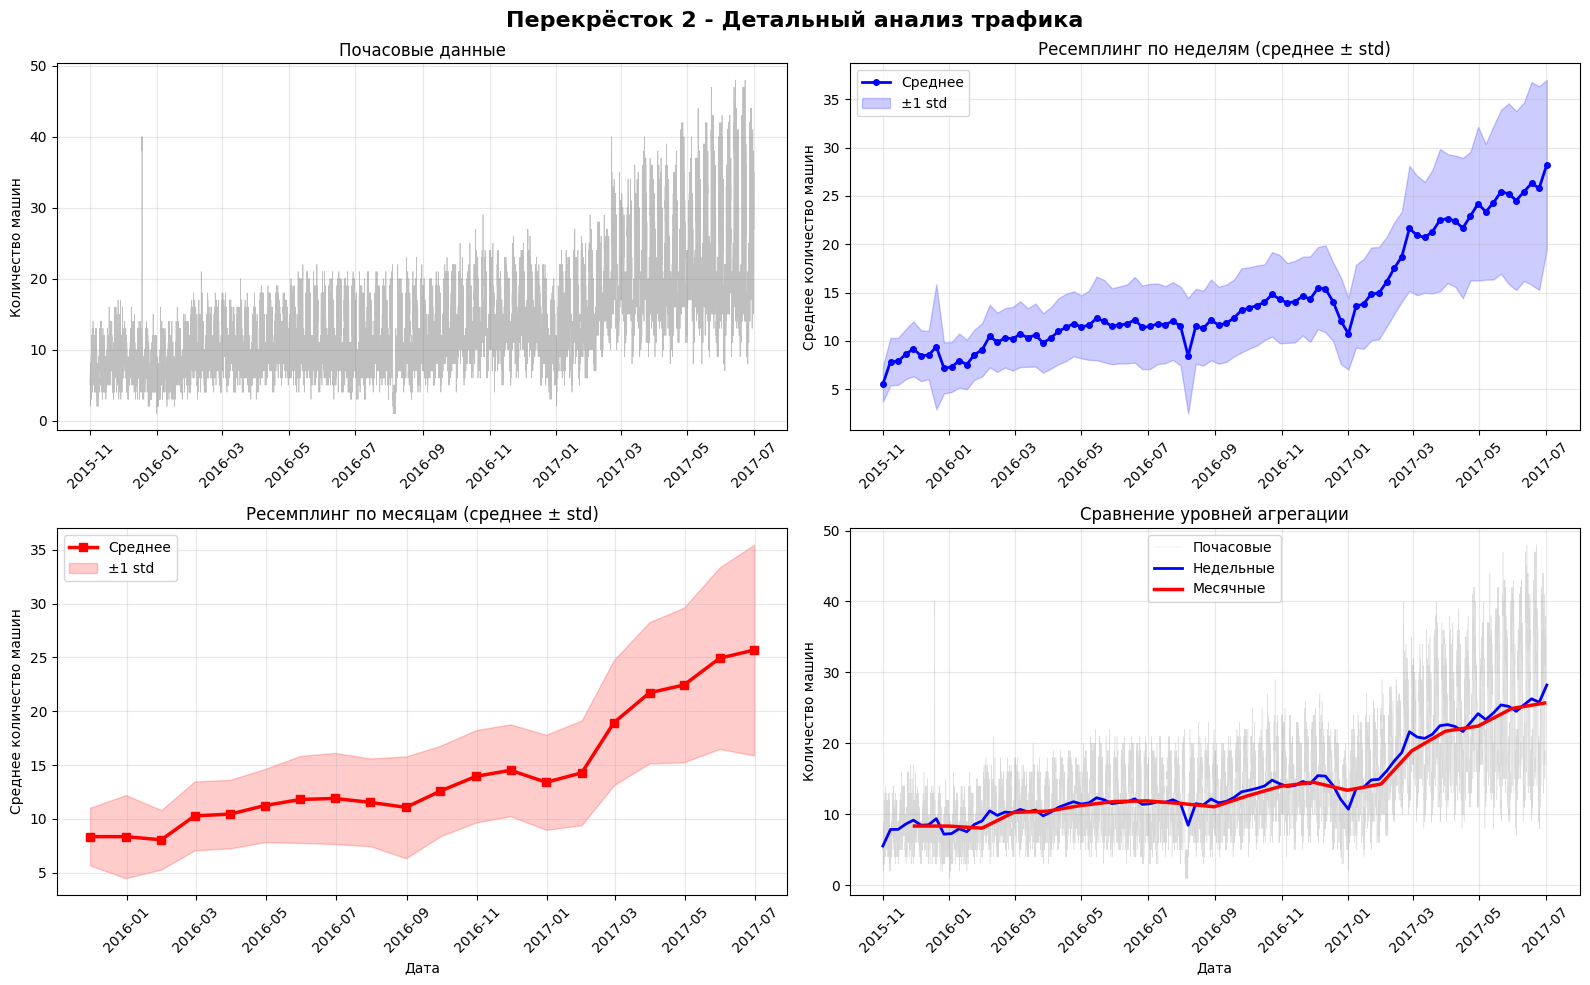

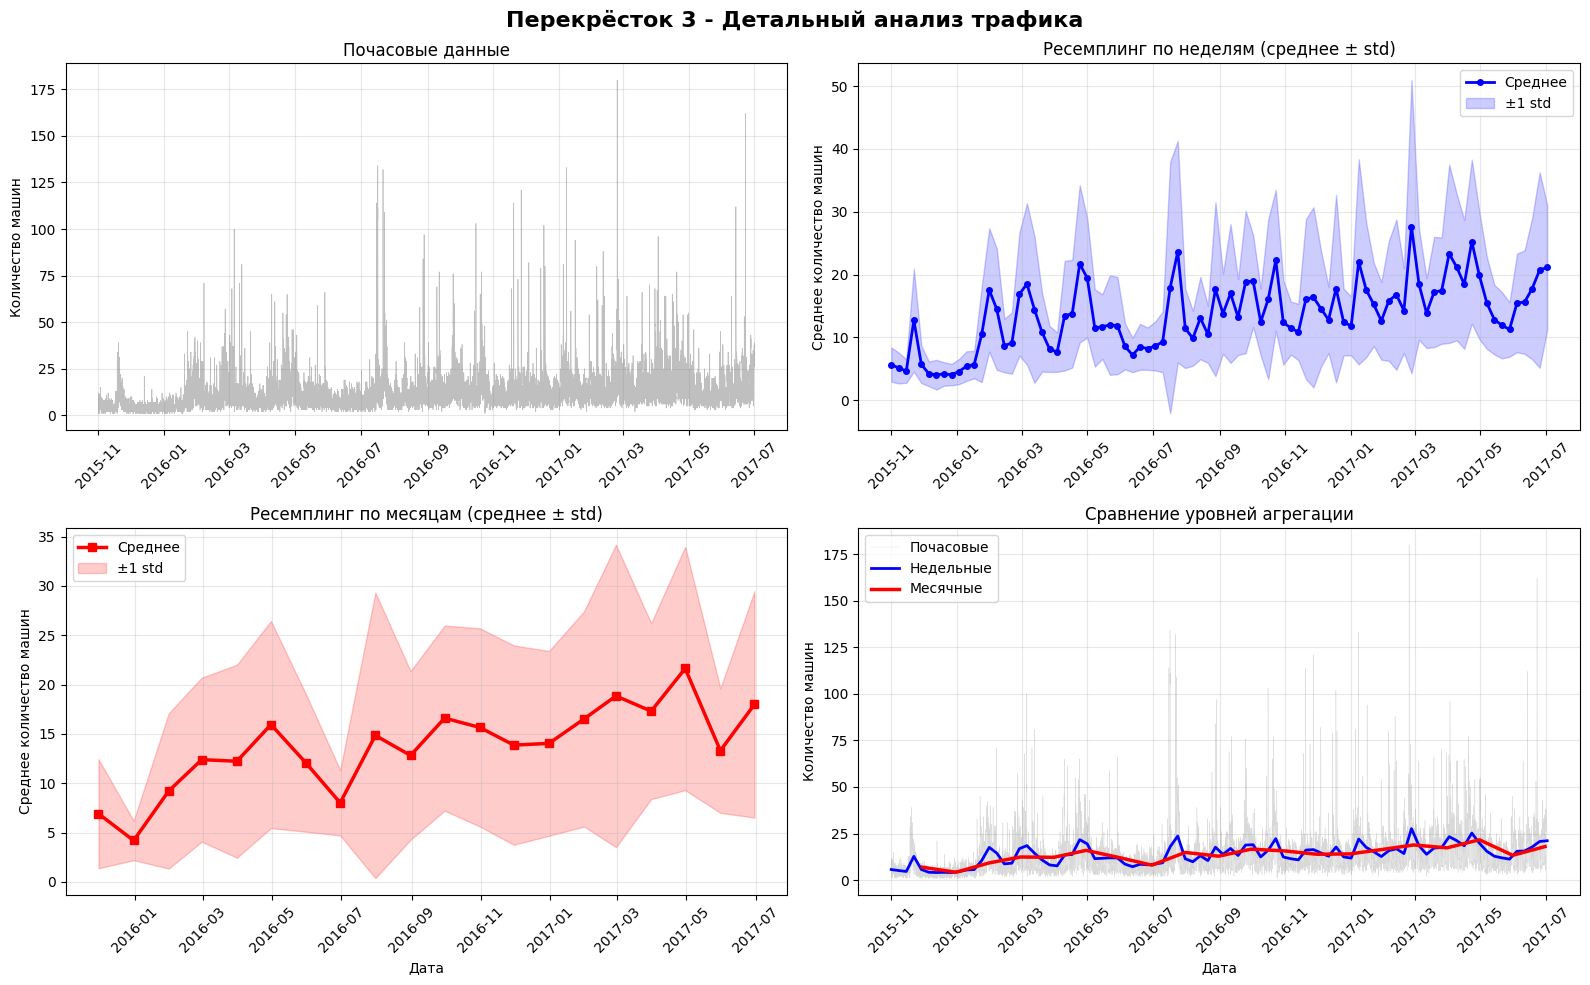

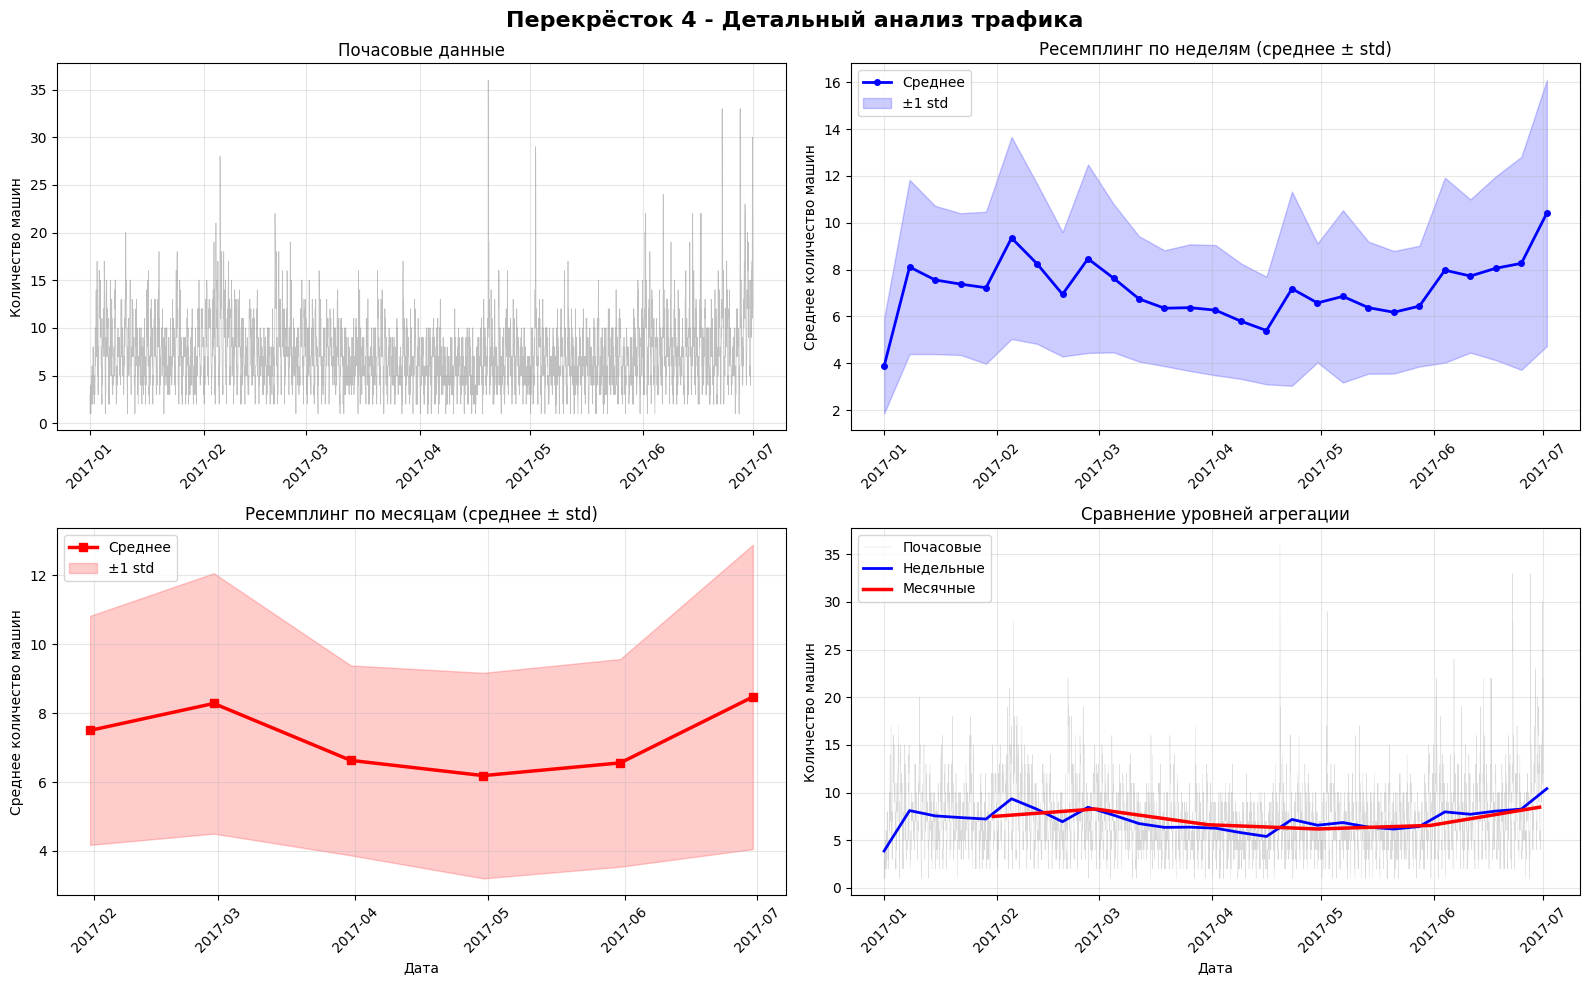

In [11]:
df_work = df_sorted.copy()

for junction in junctions:
    data = df_work[df_work['Junction'] == junction]['Vehicles'].copy()

    # ресемплинг с разными агрегациями
    weekly_mean = data.resample('W').mean()
    weekly_std = data.resample('W').std()
    monthly_mean = data.resample('ME').mean()
    monthly_std = data.resample('ME').std()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Перекрёсток {junction} - Детальный анализ трафика', fontsize=16, fontweight='bold')

    # исходные данные
    axes[0, 0].plot(data.index, data.values, linewidth=0.5, alpha=0.5, color='gray')
    axes[0, 0].set_title('Почасовые данные', fontsize=12)
    axes[0, 0].set_ylabel('Количество машин')
    axes[0, 0].grid(True, alpha=0.3)

    # недельный ресемплинг (среднее + std)
    axes[0, 1].plot(weekly_mean.index, weekly_mean.values, linewidth=2, color='blue', marker='o', markersize=4, label='Среднее')
    axes[0, 1].fill_between(weekly_mean.index,
                            weekly_mean.values - weekly_std.values,
                            weekly_mean.values + weekly_std.values,
                            alpha=0.2, color='blue', label='±1 std')
    axes[0, 1].set_title('Ресемплинг по неделям (среднее ± std)', fontsize=12)
    axes[0, 1].set_ylabel('Среднее количество машин')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # месячный ресемплинг (среднее + std)
    axes[1, 0].plot(monthly_mean.index, monthly_mean.values, linewidth=2.5, color='red', marker='s', markersize=6, label='Среднее')
    axes[1, 0].fill_between(monthly_mean.index,
                            monthly_mean.values - monthly_std.values,
                            monthly_mean.values + monthly_std.values,
                            alpha=0.2, color='red', label='±1 std')
    axes[1, 0].set_title('Ресемплинг по месяцам (среднее ± std)', fontsize=12)
    axes[1, 0].set_ylabel('Среднее количество машин')
    axes[1, 0].set_xlabel('Дата')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # сравнение гарфиков ресемплинга
    axes[1, 1].plot(data.index, data.values, linewidth=0.3, alpha=0.3, color='gray', label='Почасовые')
    axes[1, 1].plot(weekly_mean.index, weekly_mean.values, linewidth=2, color='blue', label='Недельные')
    axes[1, 1].plot(monthly_mean.index, monthly_mean.values, linewidth=2.5, color='red', label='Месячные')
    axes[1, 1].set_title('Сравнение уровней агрегации', fontsize=12)
    axes[1, 1].set_ylabel('Количество машин')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

1.   ПРЕКРЕСТОК 1

При ресемплинге по неделям явно виден восходящий тренд. Значительное провисание приходится на Новогоднее время 2016 и 2017 гг. Есть и другие колебания. Их нужно будет анализировать отдельно. На графике респемлинга по годам тренд видет еще ярче.

2.   ПРЕКРЕСТОК 2

При ресемплинге по неделям видна схожая картина - рост загруженности перекрестка. Довольно значительный провал на Новый год и в промежуток с 2016-07 и 2016-09.

3.   ПРЕКРЕСТОК 3

На графика ресемплинга по неделям видно множество колебаний. На графике динамики трафика по месяцам обнаружился возрастающий тренд: на начало периода среднее > 5, на конец > 15. Рост есть, хотя, конечно, не такой сильный как на перекрестках 1-2. На этом перекрестке ярковыраженного спада в Новый год мы не наблюдаем.

4.   ПРЕКРЕСТОК 4

На графике ресемплинга по неделям видны колебания. По месяцам - график довольно плавный, можно предположить, что график близок к плоской синусоиде, где график весной-летом ближе к оси х, а осенью-зимой дальше от оси х.



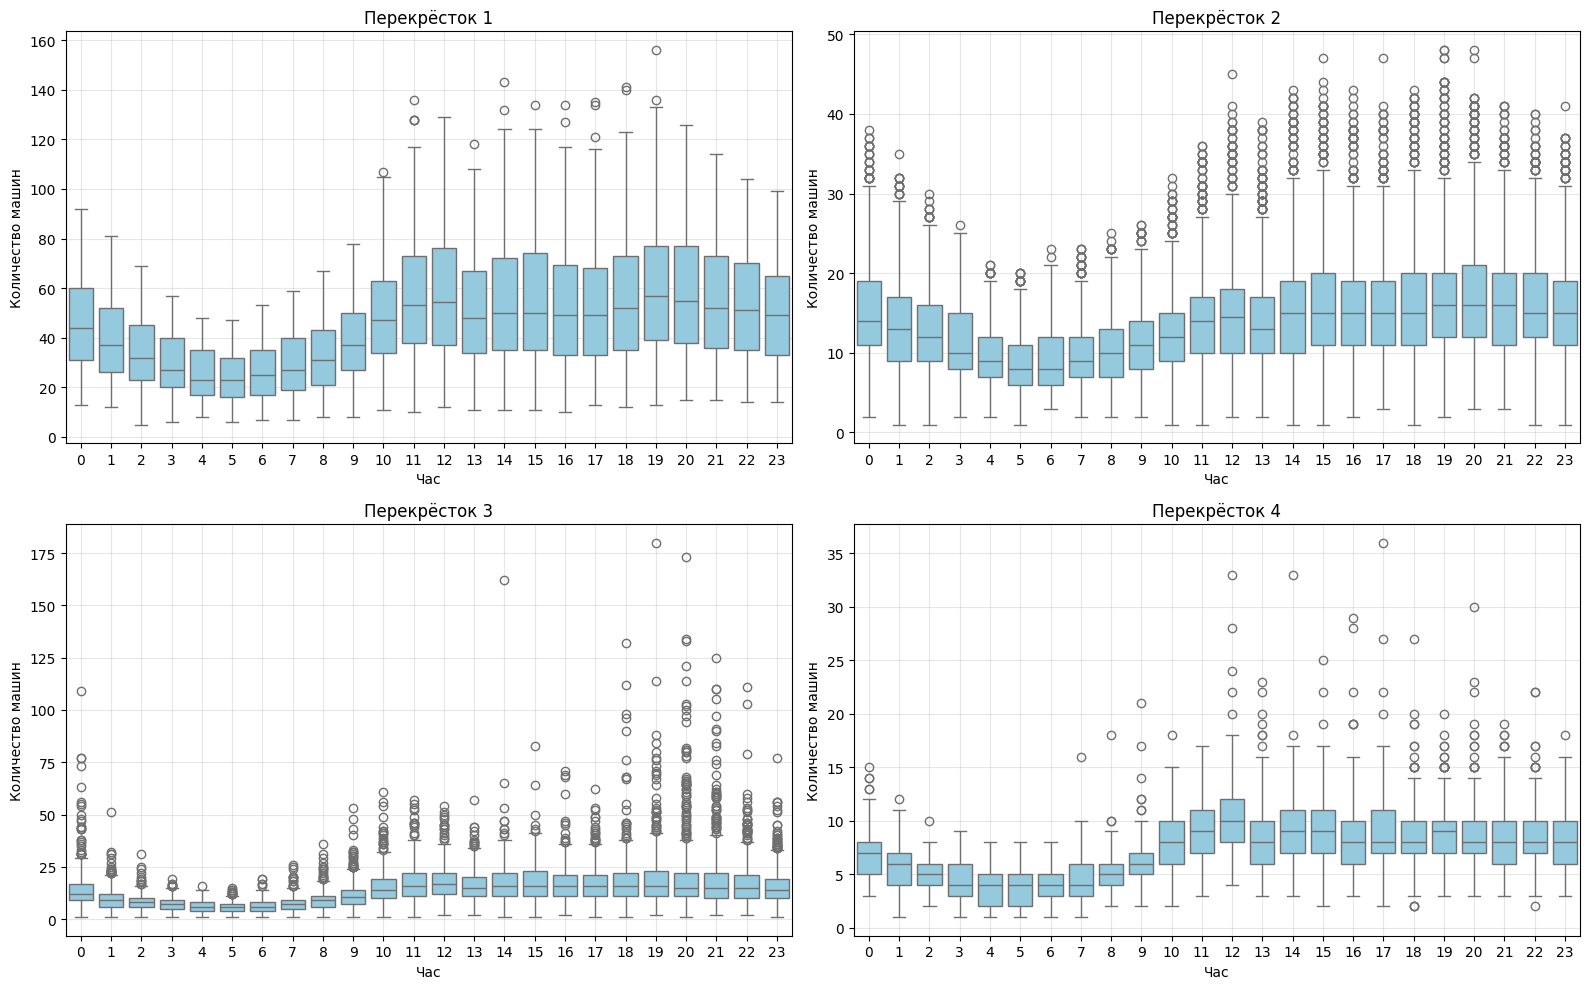

In [12]:
# загруженность перекрестков по часам
df_sorted['hour'] = df_sorted.index.hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, junction in enumerate(junctions):
    data = df_sorted[df_sorted['Junction'] == junction]
    sns.boxplot(data=data, x='hour', y='Vehicles', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Перекрёсток {junction}', fontsize=12)
    axes[i].set_xlabel('Час')
    axes[i].set_ylabel('Количество машин')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Посмотрим загруженность перекрестков по времени суток.

По графикам видно, что динамика изменения трафика относительно идентична: спад на 4-5-ти, плавный подъем, пик на 11-12-ти и медленный спад до 4-5-ти.

In [13]:
# праздники
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())

# 0 - обычный день, 1 - праздник или выходной
df['is_holiday_or_weekend'] = (
    df.index.isin(holidays) | (df.index.dayofweek >= 5)
).astype(int)

print(df[['Vehicles', 'is_holiday_or_weekend']].head(5))

print("\nКоличество дней по типам:")
print(df['is_holiday_or_weekend'].value_counts().sort_index())

df.head()

                     Vehicles  is_holiday_or_weekend
DateTime                                            
2015-11-01 00:00:00        15                      1
2015-11-01 00:00:00         6                      1
2015-11-01 00:00:00         9                      1
2015-11-01 01:00:00         7                      1
2015-11-01 01:00:00        13                      1

Количество дней по типам:
is_holiday_or_weekend
0    34385
1    13735
Name: count, dtype: int64


,Junction,Vehicles,is_holiday_or_weekend
DateTime,,,
2015-11-01 00:00:00,1,15,1
2015-11-01 00:00:00,2,6,1
2015-11-01 00:00:00,3,9,1
2015-11-01 01:00:00,3,7,1
2015-11-01 01:00:00,1,13,1


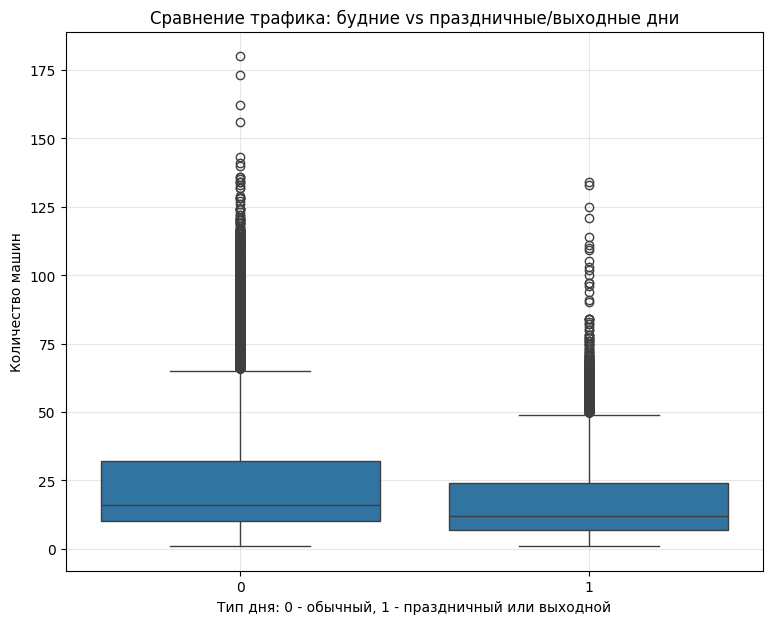

In [14]:
plt.figure(figsize=(9, 7))
sns.boxplot(data=df, x='is_holiday_or_weekend', y='Vehicles')
plt.title('Сравнение трафика: будние vs праздничные/выходные дни')
plt.xlabel('Тип дня: 0 - обычный, 1 - праздничный или выходной')
plt.ylabel('Количество машин')
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()

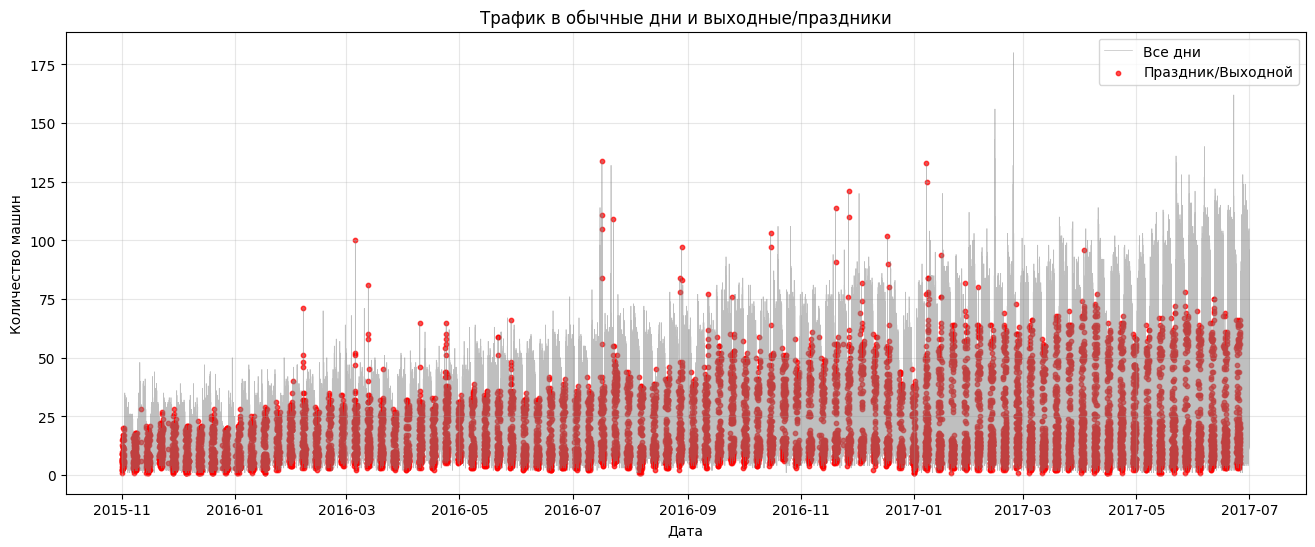

In [15]:
plt.figure(figsize=(16, 6))

plt.plot(df.index, df['Vehicles'], linewidth=0.5, alpha=0.5, color='gray', label='Все дни')

holiday_data = df[df['is_holiday_or_weekend'] == 1]
plt.scatter(holiday_data.index, holiday_data['Vehicles'],
            color='red', s=10, alpha=0.7, label='Праздник/Выходной')

plt.title('Трафик в обычные дни и выходные/праздники')
plt.xlabel('Дата')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Декомпозиция временного ряда и его свойства

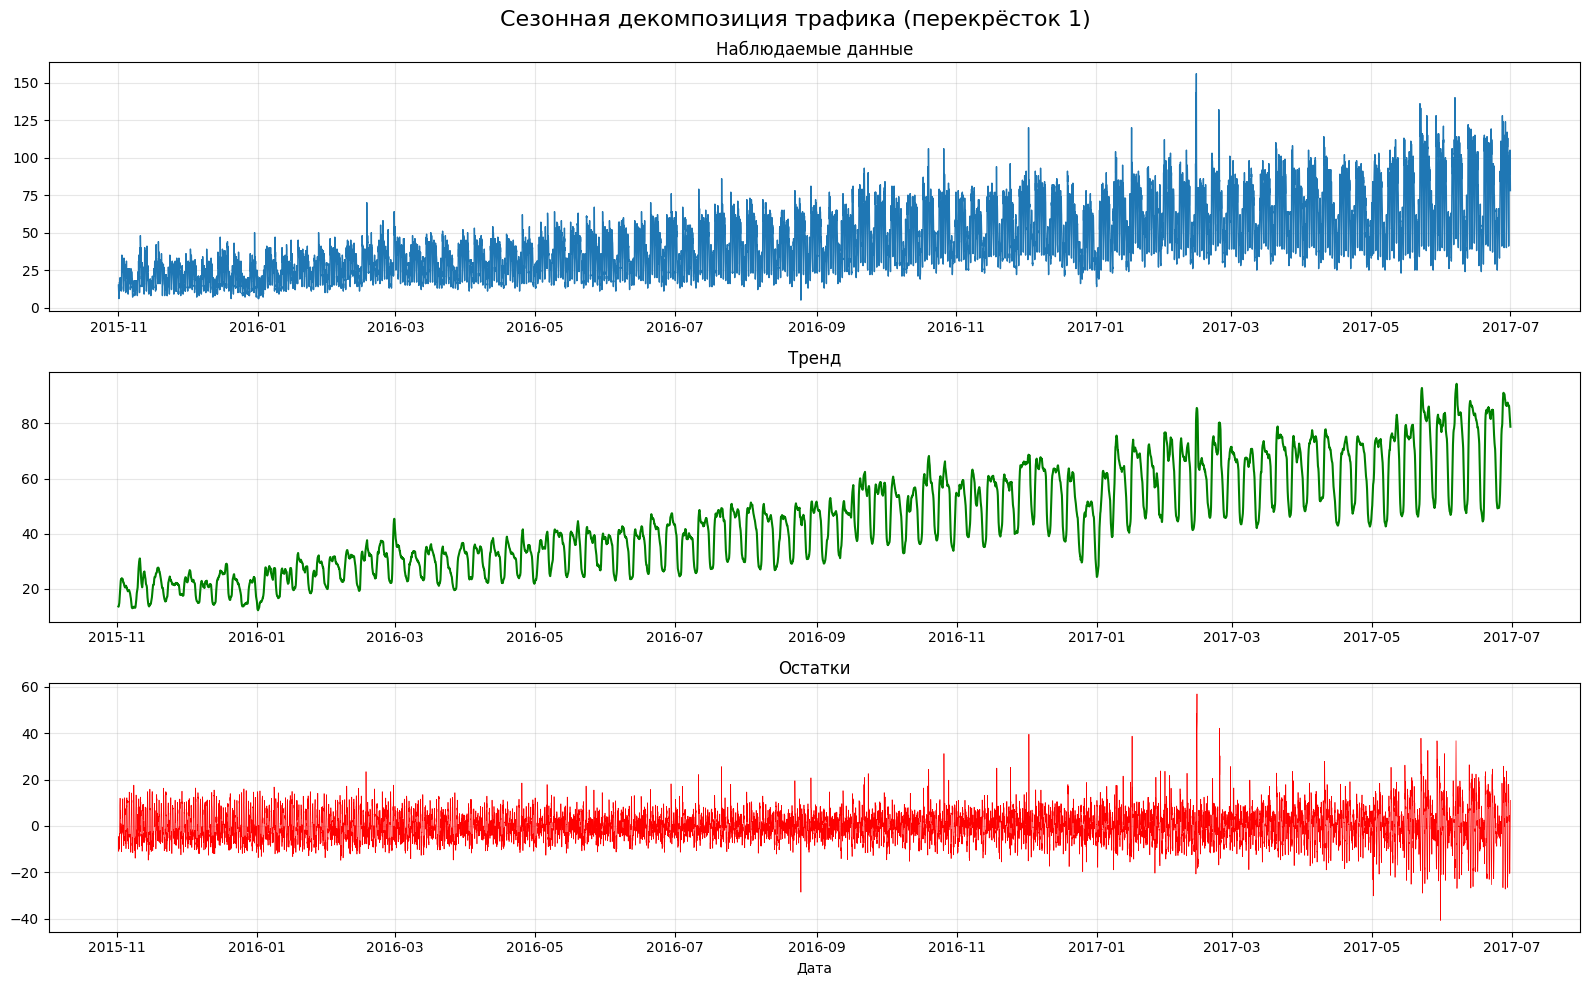

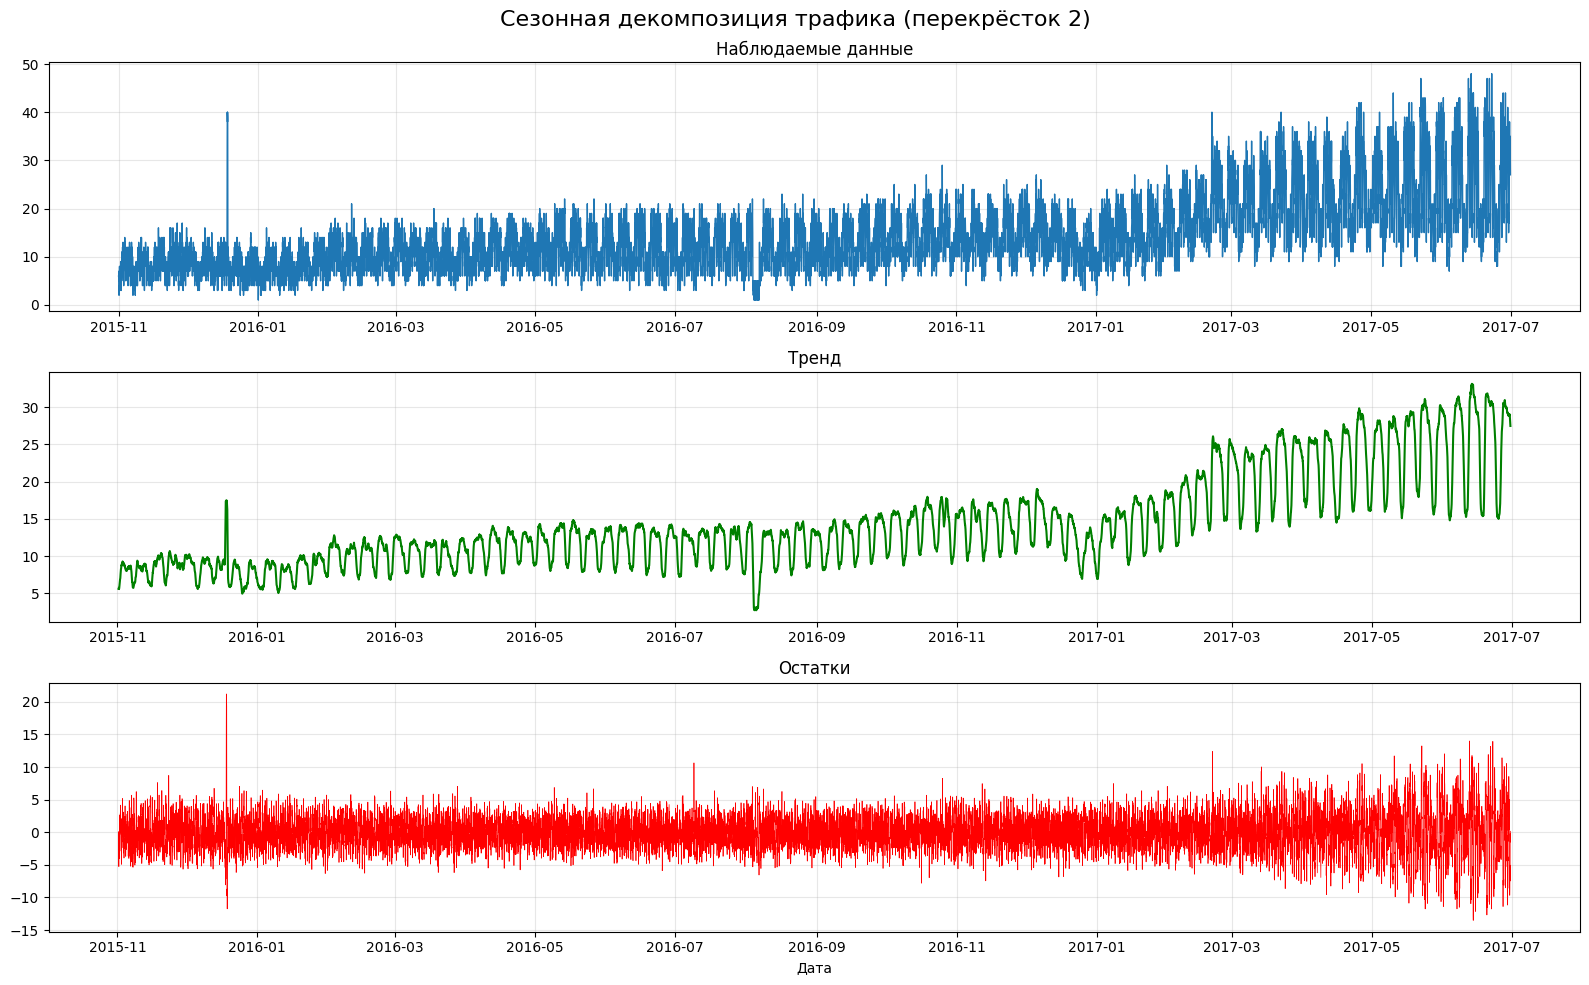

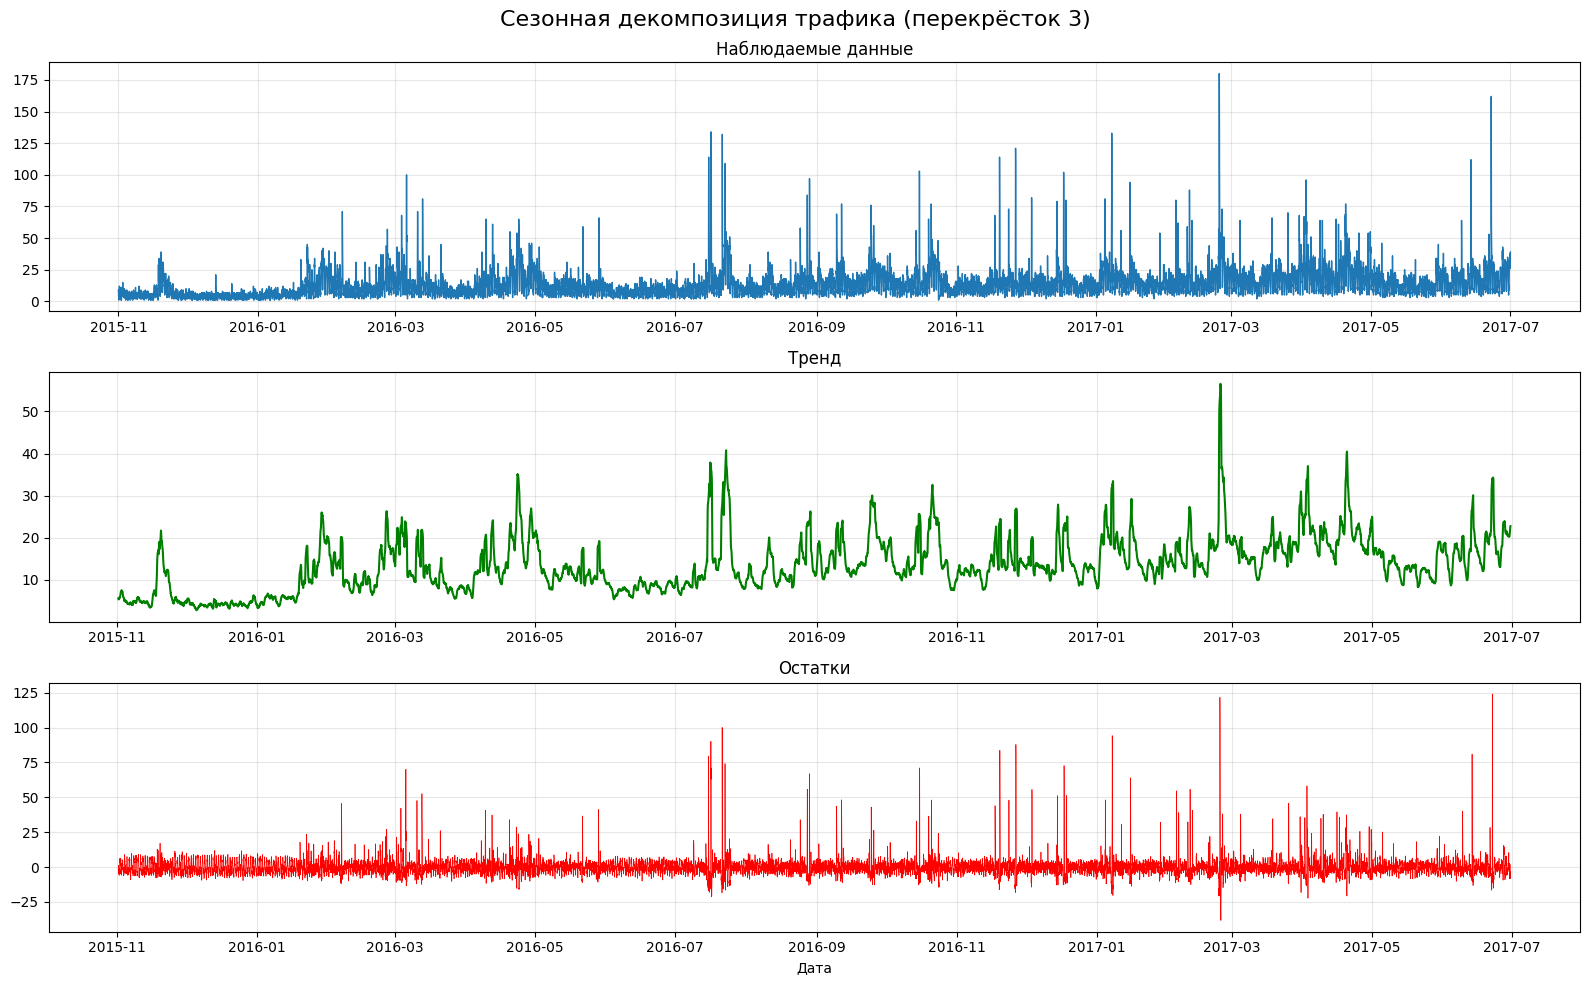

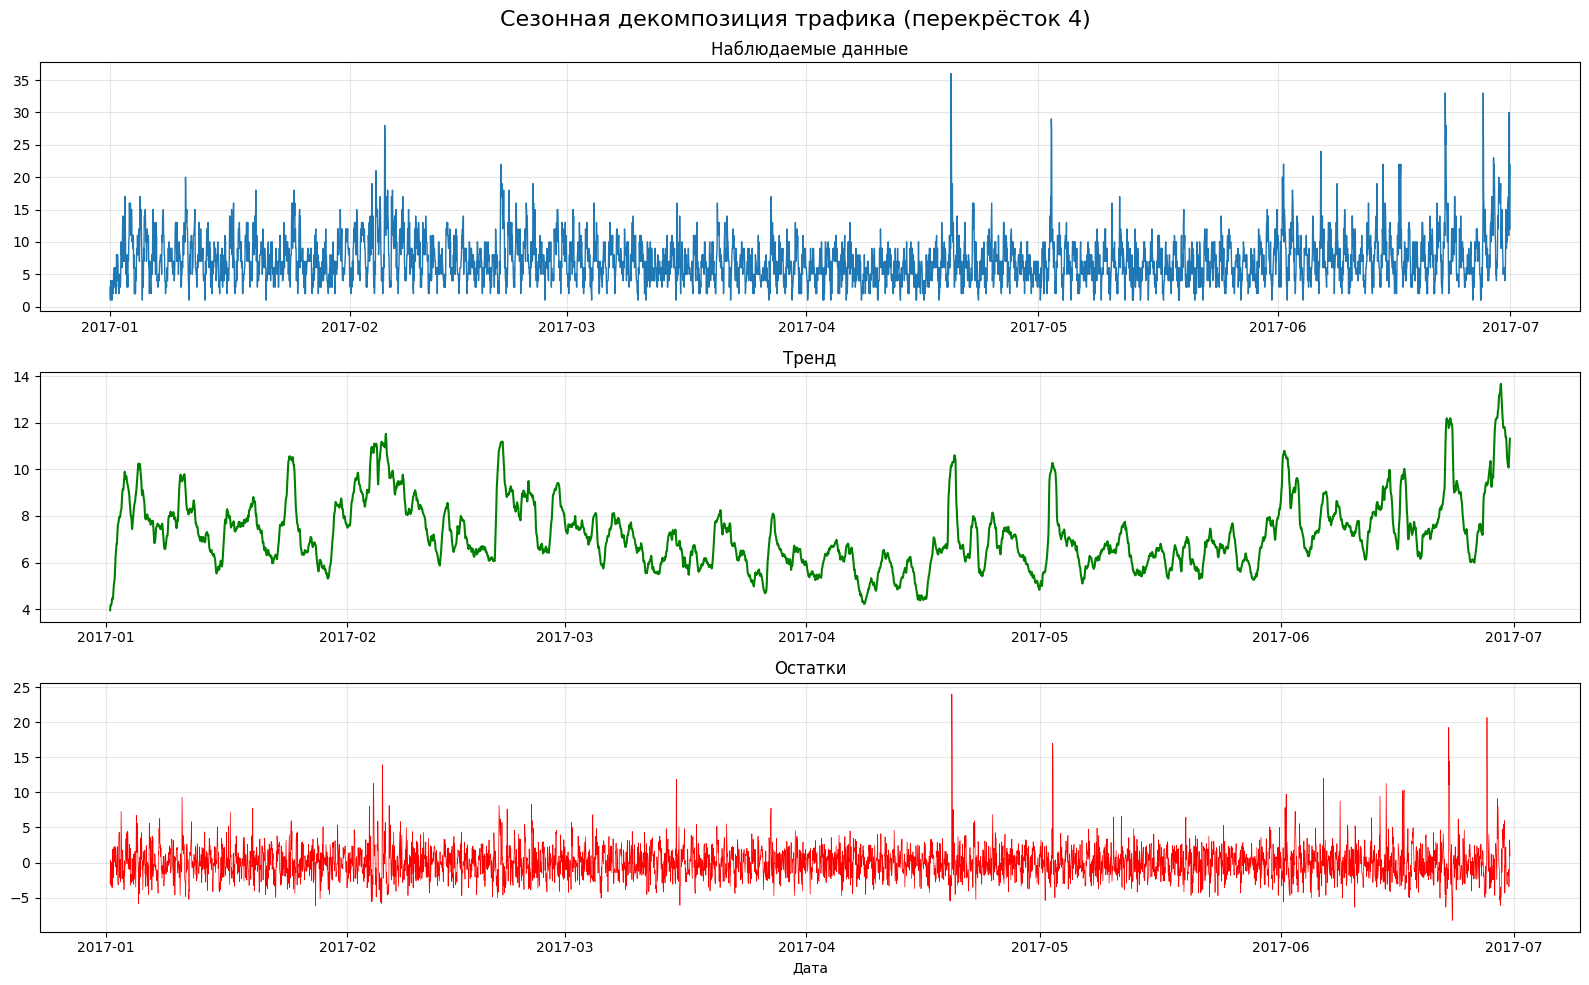

In [16]:
# декомпозиция в statsmodel
for i in junctions:
  junction_id = i
  data = df[df['Junction'] == junction_id]['Vehicles'].copy()

  decomp = seasonal_decompose(data, model='additive', period=24)

  # Визуализация
  fig, axes = plt.subplots(3, 1, figsize=(16, 10))
  fig.suptitle(f'Сезонная декомпозиция трафика (перекрёсток {junction_id})', fontsize=16)

  # данные
  axes[0].plot(decomp.observed, linewidth=1)
  axes[0].set_title('Наблюдаемые данные')
  axes[0].grid(True, alpha=0.3)

  # тренд
  axes[1].plot(decomp.trend, linewidth=1.5, color='green')
  axes[1].set_title('Тренд')
  axes[1].grid(True, alpha=0.3)

  # остатки
  axes[2].plot(decomp.resid, linewidth=0.5, color='red')
  axes[2].set_title('Остатки')
  axes[2].set_xlabel('Дата')
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

**Результаты декомпозиции**

На графиках видно, что тренд и сезонности были выделены не очень качественно: у 1 и 3 перекрестка много выбросов, у 1 и 2 после 2017-03 меняется дисперсия. Но в целом остатки 2 и 4 перекрестка выглядят неплохо.

In [17]:
# создаём отдельные датафреймы для каждого перекрестка
df_junction_1 = df[df['Junction'] == junctions[0]].copy()
df_junction_2 = df[df['Junction'] == junctions[1]].copy()
df_junction_3 = df[df['Junction'] == junctions[2]].copy()
df_junction_4 = df[df['Junction'] == junctions[3]].copy()

junctions = [df_junction_1, df_junction_2, df_junction_3, df_junction_4]

# удаляем колонку Junction из каждого
df_junction_1 = df_junction_1.drop('Junction', axis=1)
df_junction_2 = df_junction_2.drop('Junction', axis=1)
df_junction_3 = df_junction_3.drop('Junction', axis=1)
df_junction_4 = df_junction_4.drop('Junction', axis=1)

df_junction_4.head(3)

,Vehicles,is_holiday_or_weekend
DateTime,,
2017-01-01 00:00:00,3,1
2017-01-01 01:00:00,1,1
2017-01-01 02:00:00,4,1


### Стационарность

In [18]:
# проверим дисперсию и стандартное отклонение каждого ряда

def check_std_variance(series, num):
  print(f'Статистические свойства ВР для перекрестка {num}')
  variance1 = series['Junction'].var()
  std = np.sqrt(variance1)
  print(f"Дисперсия: {variance1:.2f}")
  print(f"Стандартное отклонение (среднее отклонение): +/- {std:.2f} машины\n")


n = 1
for i in junctions:
  check_std_variance(i, n)
  n += 1

Статистические свойства ВР для перекрестка 1
Дисперсия: 0.00
Стандартное отклонение (среднее отклонение): +/- 0.00 машины

Статистические свойства ВР для перекрестка 2
Дисперсия: 0.00
Стандартное отклонение (среднее отклонение): +/- 0.00 машины

Статистические свойства ВР для перекрестка 3
Дисперсия: 0.00
Стандартное отклонение (среднее отклонение): +/- 0.00 машины

Статистические свойства ВР для перекрестка 4
Дисперсия: 0.00
Стандартное отклонение (среднее отклонение): +/- 0.00 машины



1 - Очень высокий разброс — трафик сильно колеблется

2 - Низкий разброс — трафик стабильный

3	-	Средний разброс — трафик умеренно колеблется

4	-	Очень низкий разброс — трафик почти постоянный

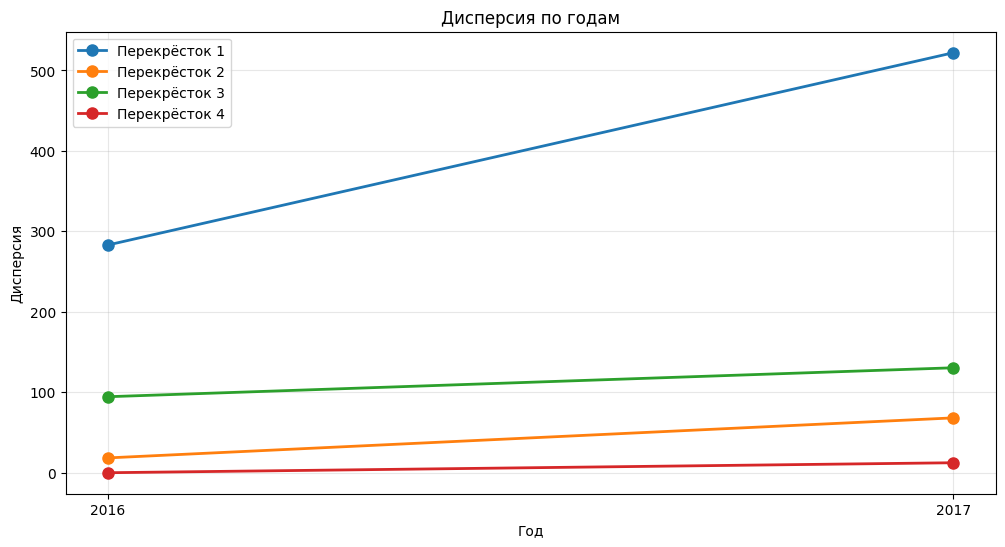

In [19]:
plt.figure(figsize=(12, 6))

years = [2016, 2017]

for i, df_j in enumerate(junctions):
    data = df_j['Vehicles']
    yearly_var = []
    for year in years:
        data_year = data[data.index.year == year]
        if len(data_year) > 0:
            yearly_var.append(data_year.var())
        else:
            yearly_var.append(0)

    plt.plot(years, yearly_var, marker='o', linewidth=2, markersize=8,
             label=f'Перекрёсток {i+1}')

plt.title('Дисперсия по годам')
plt.xlabel('Год')
plt.ylabel('Дисперсия')
plt.xticks(years)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Обратившись к графику изменения дисперсий, мы также видим:
- сильный растущий тренд у 1 перекрестка
- небольшую возрастающую динамику у 2
- заметный тренд у 3
- практически не изменяющуюся дисперсию у 4

In [20]:
# функция для проверки стационарности
def check_stationarity(series):
    """
    Проверяет стационарность ряда с помощью тестов ADF и KPSS
    """

    # Тест ADF
    adf_result = adfuller(series, autolag='AIC')
    print(f"\nТест ADF:")
    print(f"  Статистика: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Критические значения:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.4f}")

    if adf_result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд НЕ стационарен (не отвергаем H0)")

    # Тест KPSS
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"\nТест KPSS:")
    print(f"  Статистика: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Критические значения:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.4f}")

    if kpss_result[1] > 0.05:
        print("Ряд стационарен (не отвергаем H0)")
    else:
        print("Ряд НЕ стационарен (отвергаем H0)\n")

    return adf_result[1] < 0.05 and kpss_result[1] > 0.05

In [21]:
print(f'Проверка стационарности ВР для 1 Перекрестка')
check_stationarity(df_junction_1['Vehicles'])

Проверка стационарности ВР для 1 Перекрестка

Тест ADF:
  Статистика: -7.1481
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 18.7477
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)



/tmp/ipykernel_73219/3909973289.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


np.False_

In [22]:
print(f'Проверка стационарности ряда ВР 2 Перекрестка')
check_stationarity(df_junction_2['Vehicles'])

Проверка стационарности ряда ВР 2 Перекрестка

Тест ADF:
  Статистика: -8.0411
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 15.1994
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)



/tmp/ipykernel_73219/3909973289.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


np.False_

In [23]:
print(f'Проверка стационарности ВР для 3 Перекрестка')
check_stationarity(df_junction_3['Vehicles'])

Проверка стационарности ВР для 3 Перекрестка

Тест ADF:
  Статистика: -8.2366
  p-value: 0.0000
  Критические значения:
    1%: -3.4308
    5%: -2.8617
    10%: -2.5669
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 7.3218
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)



/tmp/ipykernel_73219/3909973289.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


np.False_

In [24]:
print(f'Проверка стационарности ВР для 4 Перекрестка')
check_stationarity(df_junction_4['Vehicles'])

Проверка стационарности ВР для 4 Перекрестка

Тест ADF:
  Статистика: -6.7267
  p-value: 0.0000
  Критические значения:
    1%: -3.4319
    5%: -2.8622
    10%: -2.5671
Ряд стационарен (отвергаем H0)

Тест KPSS:
  Статистика: 0.9476
  p-value: 0.0100
  Критические значения:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Ряд НЕ стационарен (отвергаем H0)



/tmp/ipykernel_73219/3909973289.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


np.False_

Для всех 4 перекрестков мы видим схожую ситуации: результаты тестов ADF и KPSS противоречат друг другу. Однако, обратившись к результатам вычислений дисперсии, стандартного отклонения, изменения среднего, графиков декомпозиции,, можно признать временные ряды 1-3 перекрестка нестационарными, а 4 - стационарным.

### Отчет по EDA

Датасет содержит почасовые данные о количестве автомобилей на 4 перекрёстках за период с ноября 2015 по июнь 2017. Пропусков нет, шаг временного ряда регулярный (почасовой). Удалила неинформативный столбец ID. Установлен индекс datetime (из соответствующей колонки). Для трех перекрестков есть информация на 608 дней, для четвёртого — 181 день. Данные не содержат дубликаты и пропуски.

На основе анализа графиков установлены различия в уровне и характере трафика по перекресткам:
Перекресток 1 — самый загруженный (среднее ~45 машин/час), наблюдается восходящий тренд.
Перекресток 2 — примерно в 3 раза менее загружен (среднее ~14), также имеет тренд на рост.
Перекресток 3 — схож по уровню с перекрестком 2, но без выраженного тренда, присутствуют заметные выбросы.
Перекресток 4 — наименее загружен (среднее ~7), также без тренда, но с выбросами.

Проведён ресемплинг данных по неделям и месяцам (среднее, стандартное отклонение, дисперсия). На графиках сопоставлены исходные почасовые данные, недельные и месячные средние. Это позволило оценить общие тренды и сезонные колебания на разных временных масштабах.

Учитывая вышеописанное, необходимо моделировать каждый перекресток отдельно.У временных рядов ярко выражена суточная, недельная и месячная сезонность. Есть возрастающий тренд.


## Cтатистические методы анализа ВР


### Подготовка датасета

In [46]:
df2 = pd.read_csv('https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/fd0f3aeec3bfe81887226bc668e4e1a7cefb0dd2/OLD%20Versions/2026/datasets/Traffic%20Prediction/traffic.csv')
df2.drop('ID', axis=1, inplace=True)
df2['DateTime'] = pd.to_datetime(df2['DateTime'])
df2.set_index('DateTime', inplace=True)
df2 = df2.sort_index()

junctions = sorted(df['Junction'].unique())
horizon = 5

# train-test split
train_dfs = {}
test_dfs = {}
for j in junctions:
    series = df2[df2['Junction'] == j]['Vehicles']
    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]

    train_df = pd.DataFrame({
        'unique_id': f'J{j}',
        'ds': train.index,
        'y': train.values
    })
    test_df = pd.DataFrame({
        'unique_id': f'J{j}',
        'ds': test.index,
        'y': test.values
    })
    train_dfs[j] = train_df
    test_dfs[j] = test_df

### 1. Statsforecast: Naive и SeasonalNaive

In [47]:
naive_models = {
    'Naive': Naive(),
    'SeasonalNaive': SeasonalNaive(season_length=24)
}

results_naive = {}
for name, model in naive_models.items():
    preds = {}
    for j in junctions:
        sf = StatsForecast(models=[model], freq='h')
        sf.fit(train_dfs[j])
        forecast = sf.predict(h=horizon)
        preds[j] = forecast[name].values
    results_naive[name] = preds

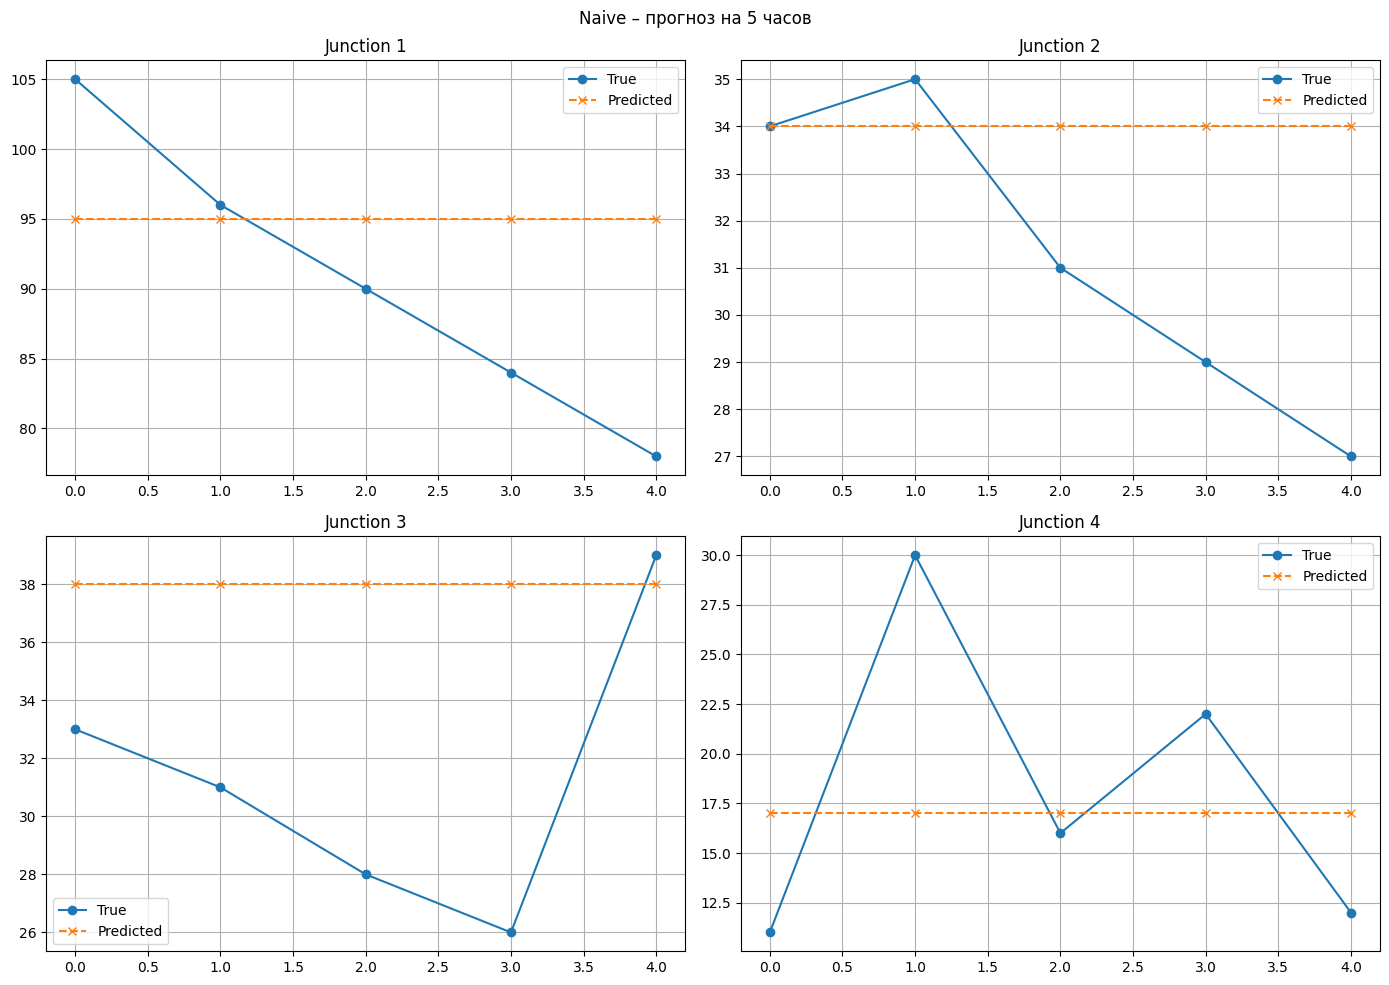

Naive: RMSE = 7.40, MSE = 59.75


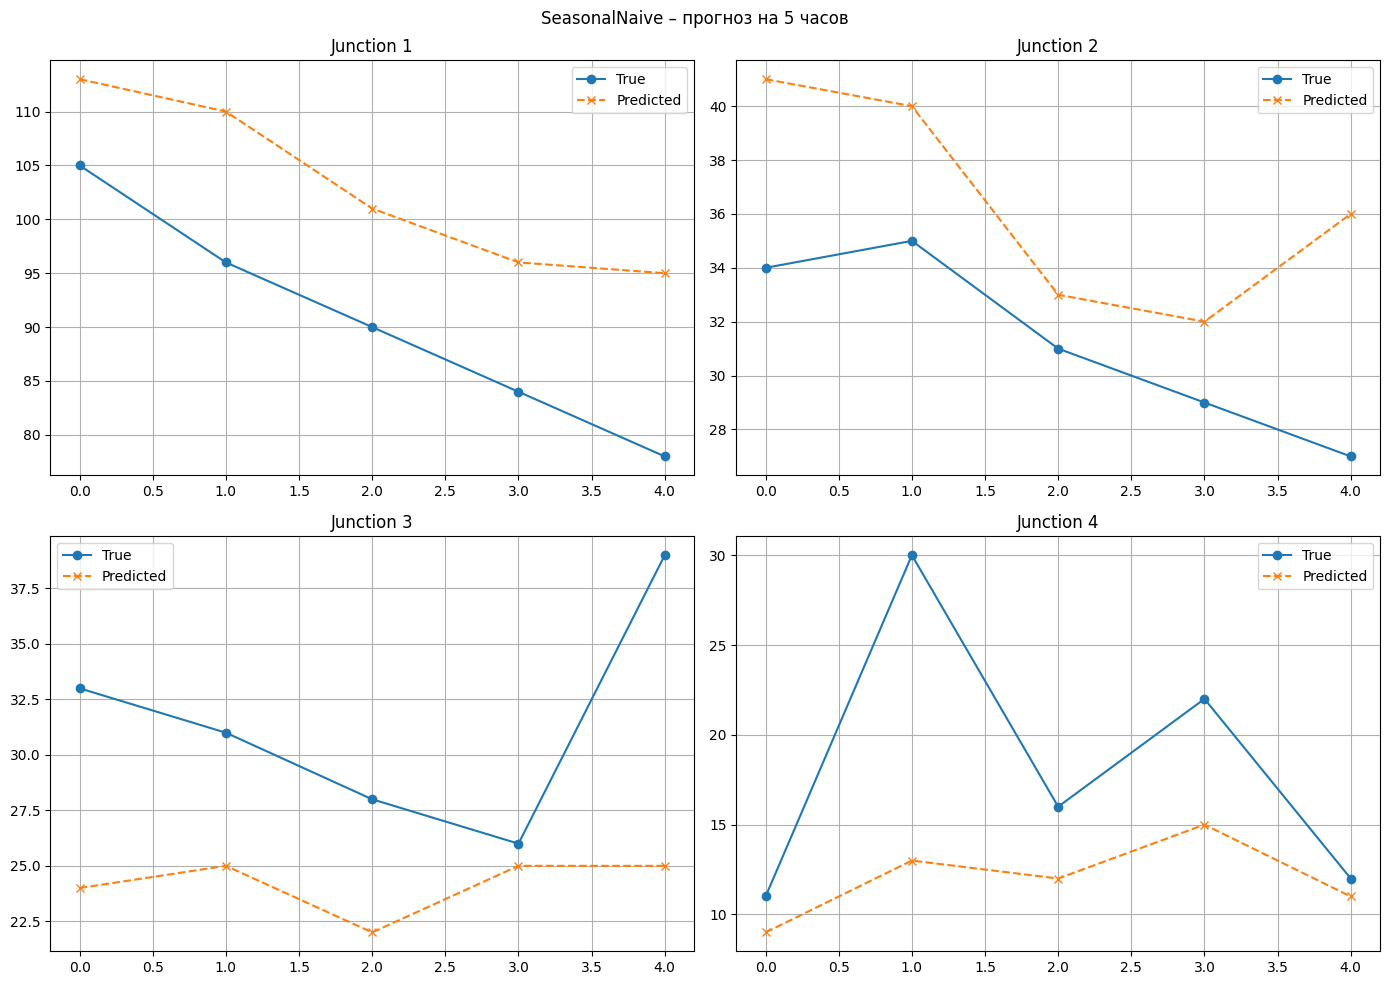

SeasonalNaive: RMSE = 8.85, MSE = 84.55


In [48]:
# Визуализация и метрики
for name, preds in results_naive.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    rmse_list, mse_list = [], []
    for i, j in enumerate(junctions):
        y_true = test_dfs[j]['y'].values
        y_pred = preds[j]
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mse_list.append(mse); rmse_list.append(rmse)
        ax = axes[i]
        ax.plot(y_true, label='True', marker='o')
        ax.plot(y_pred, '--', label='Predicted', marker='x')
        ax.set_title(f'Junction {j}')
        ax.legend()
        ax.grid(True)
    plt.suptitle(f'{name} – прогноз на 5 часов')
    plt.tight_layout()
    plt.show()
    print(f"{name}: RMSE = {np.mean(rmse_list):.2f}, MSE = {np.mean(mse_list):.2f}")

* Naive: RMSE = 7.40, MSE = 59.75
* SeasonalNaive: RMSE = 8.85, MSE = 84.55

Проанализируем графики:

- Naive не справился с задачей.

- SeasonalNaive отчасти повторяет динамику реального временного ряа, но тоже сильно ошибается.

###2. ARIMA и AutoARIMA


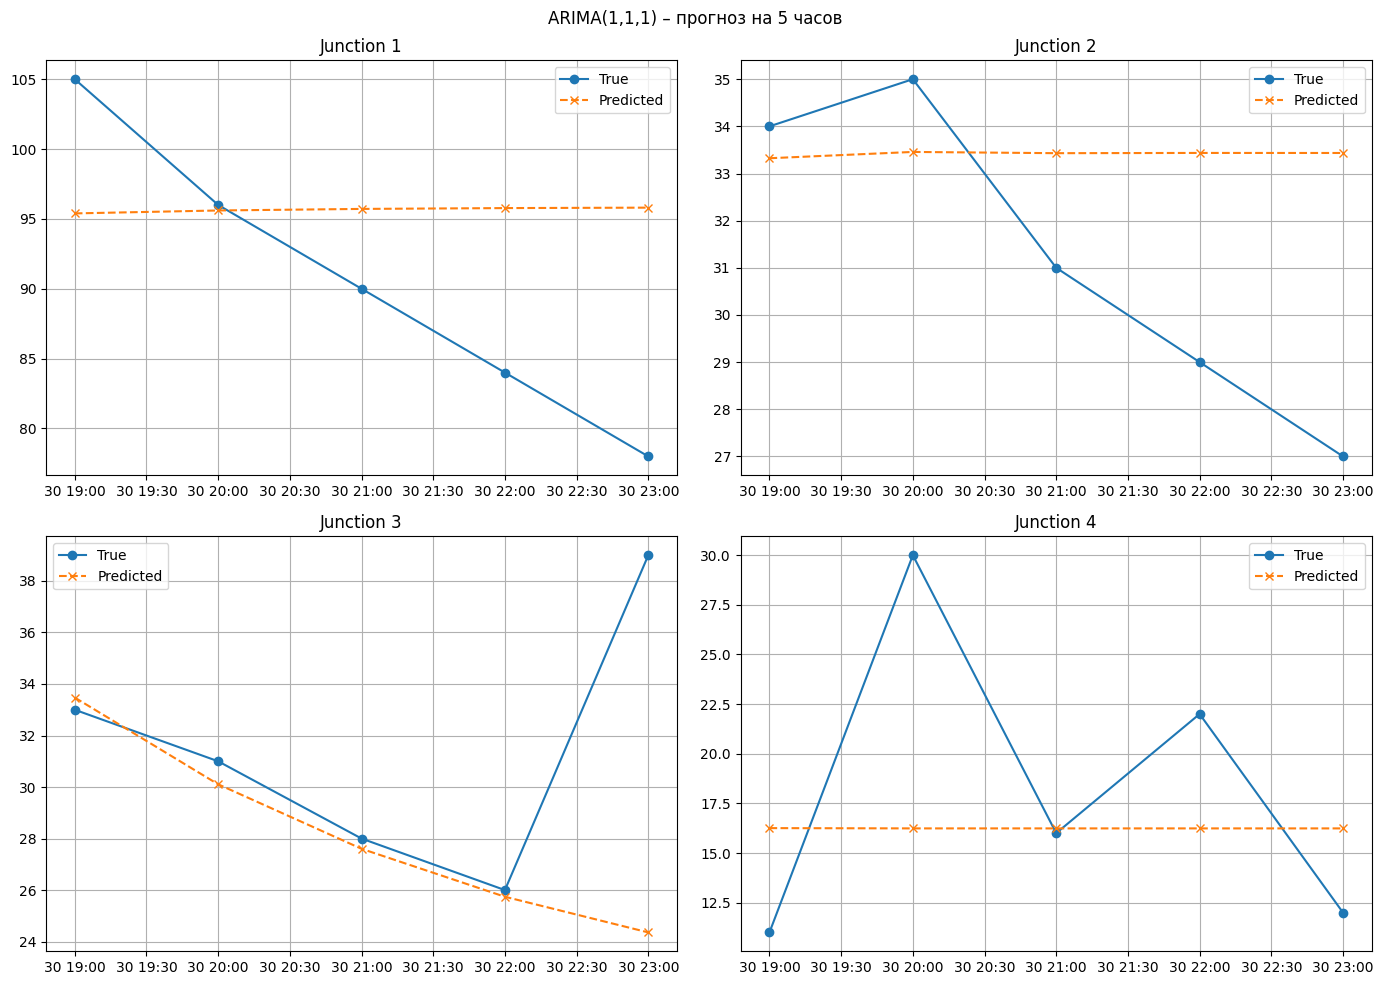

ARIMA(1,1,1): RMSE = 7.10, MSE = 56.72


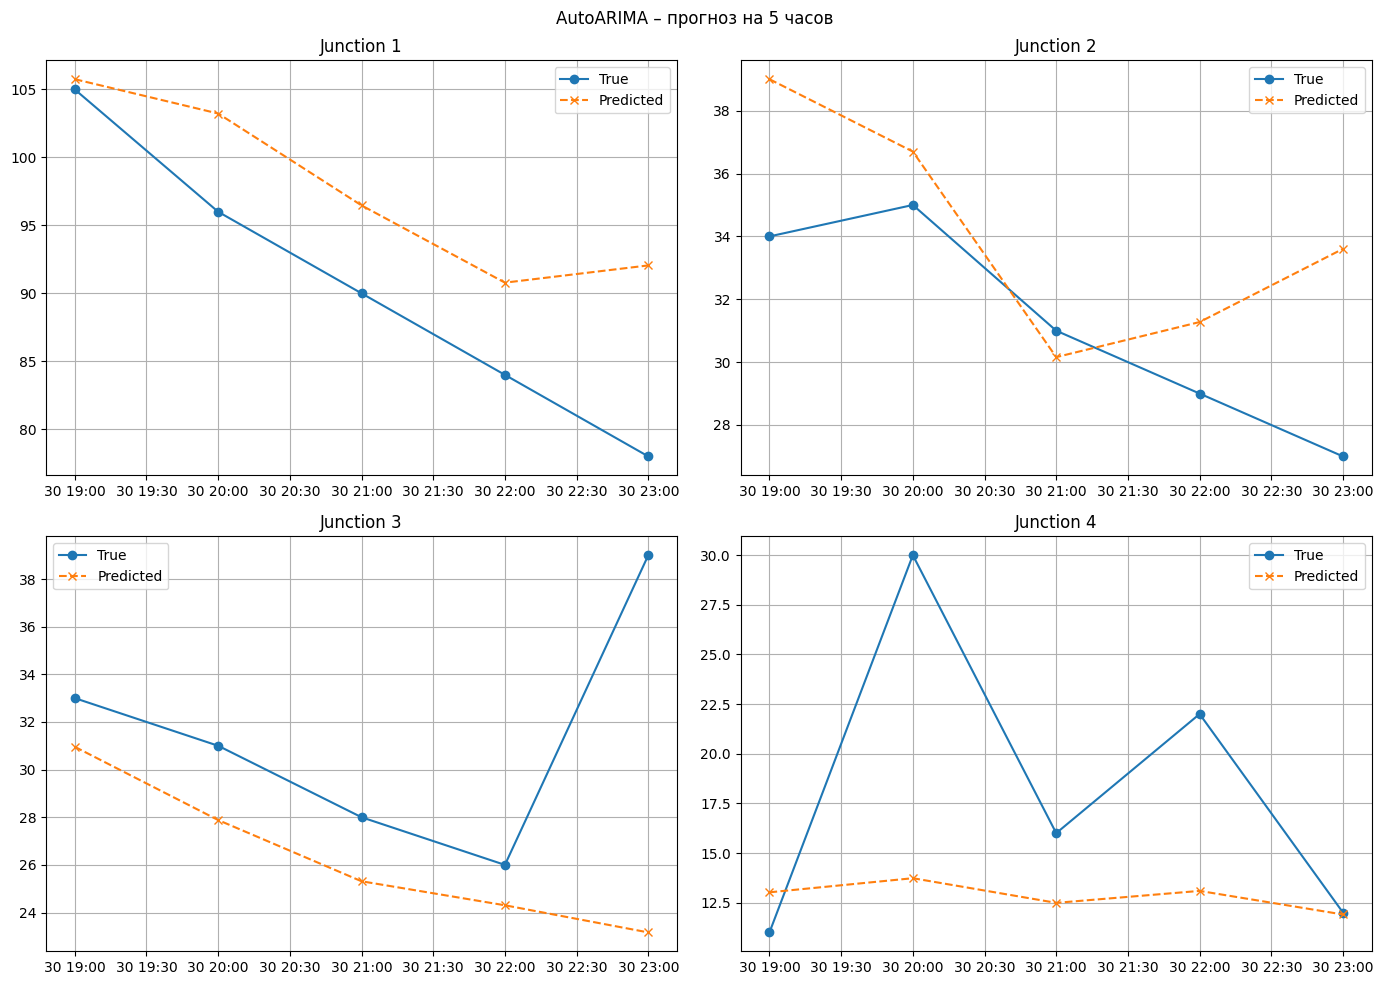

AutoARIMA: RMSE = 7.02, MSE = 52.54


In [56]:
arima_models = {
    'ARIMA(1,1,1)': ARIMA(order=(1,1,1), alias='ARIMA(1,1,1)'),
    'AutoARIMA': AutoARIMA(season_length=24, alias='AutoARIMA')
}

results_arima = {}
for name, model in arima_models.items():
    preds = {}
    for j in junctions:
        sf = StatsForecast(models=[model], freq='h')
        sf.fit(train_dfs[j])
        forecast = sf.predict(h=horizon)
        preds[j] = forecast[name].values
    results_arima[name] = preds

# Визуализация и метрики
for name, preds in results_arima.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    rmse_list, mse_list = [], []
    for i, j in enumerate(junctions):
        test_df = test_dfs[j]
        y_true = test_df['y'].values
        y_pred = preds[j]
        min_len = min(len(y_true), len(y_pred))
        y_true_trim = y_true[:min_len]
        y_pred_trim = y_pred[:min_len]
        mse = mean_squared_error(y_true_trim, y_pred_trim)
        rmse = np.sqrt(mse)
        mse_list.append(mse); rmse_list.append(rmse)
        ax = axes[i]
        dates = test_df['ds'].values[:min_len]
        ax.plot(dates, y_true_trim, label='True', marker='o')
        ax.plot(dates, y_pred_trim, '--', label='Predicted', marker='x')
        ax.set_title(f'Junction {j}')
        ax.legend()
        ax.grid(True)
        if len(y_pred) < horizon:
            print(f"Warning: для Junction {j} прогноз содержит {len(y_pred)} точек вместо {horizon}")
    plt.suptitle(f'{name} – прогноз на {horizon} часов')
    plt.tight_layout()
    plt.show()
    print(f"{name}: RMSE = {np.mean(rmse_list):.2f}, MSE = {np.mean(mse_list):.2f}")

- ARIMA(1,1,1): RMSE = 7.10, MSE = 56.72
- AutoARIMA: RMSE = 7.02, MSE = 52.54

Проанализируем графики:

- ARIMA(1,1,1) хорошо предсказала 4 лага для 3 перекрестка.
- AutoARIMA: более-менее предсказала 4 лага для 1-3 перекрестка.

###3. ETS


In [49]:
ets_model = ETS(season_length=24)
preds_ets = {}
for j in junctions:
    sf = StatsForecast(models=[ets_model], freq='h')
    sf.fit(train_dfs[j])
    forecast = sf.predict(h=horizon)
    preds_ets[j] = forecast['ETS'].values

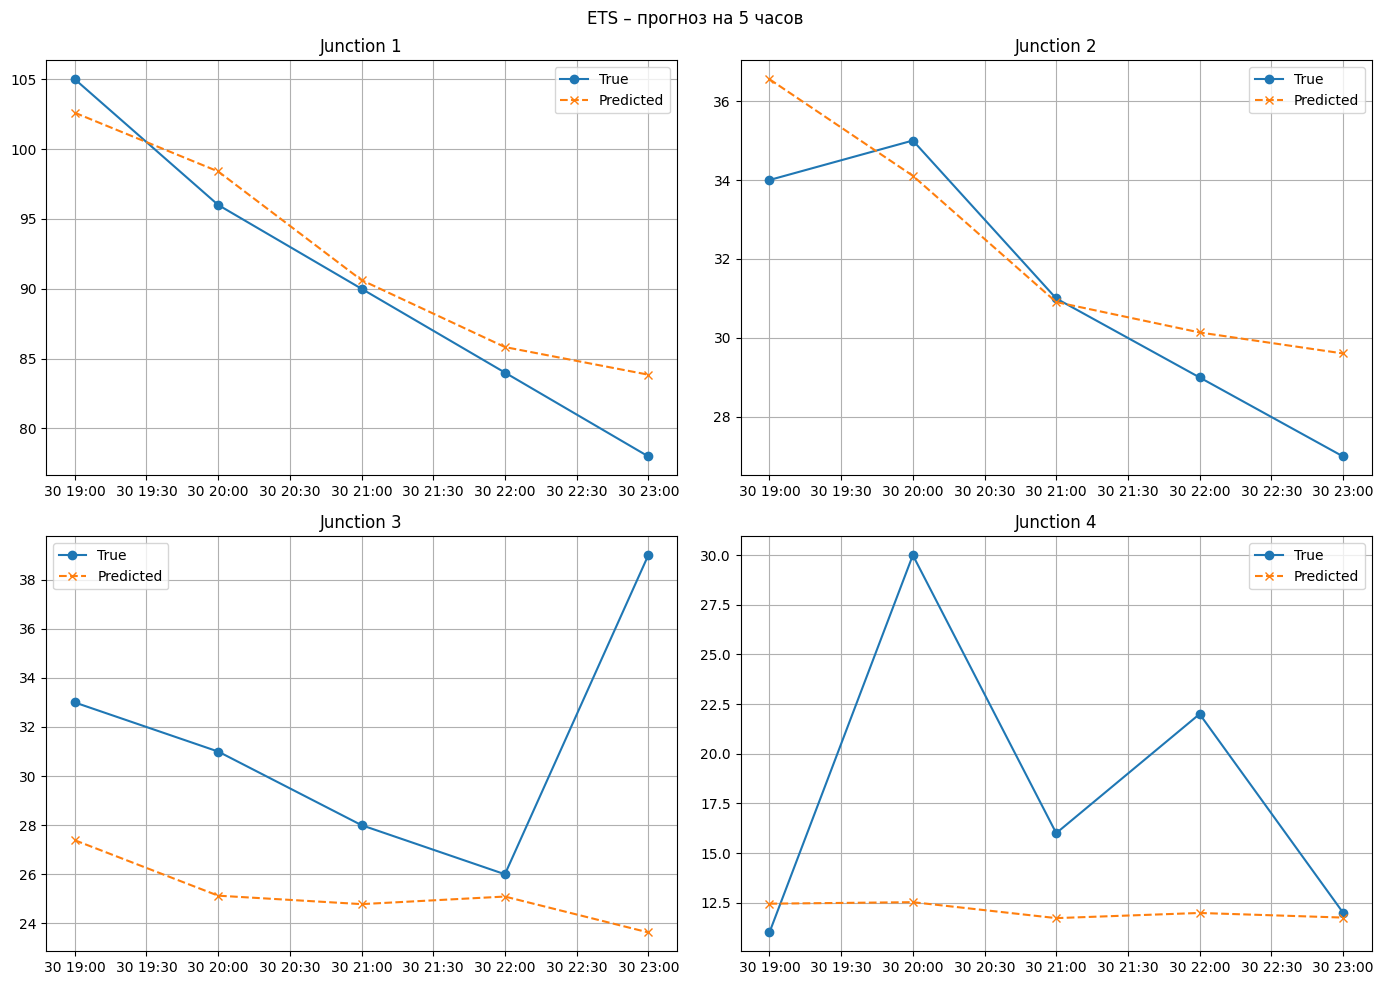

ETS: RMSE = 5.51, MSE = 40.23


In [50]:
# визуализация и метрики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
rmse_list, mse_list = [], []

for i, j in enumerate(junctions):
    test_df = test_dfs[j]

    y_true = test_dfs[j]['y'].values
    y_pred = preds_ets[j]

    min_len = min(len(y_true), len(y_pred))
    y_true_trim = y_true[:min_len]
    y_pred_trim = y_pred[:min_len]

    mse = mean_squared_error(y_true_trim, y_pred_trim)
    rmse = np.sqrt(mse)
    mse_list.append(mse)
    rmse_list.append(rmse)

    ax = axes[i]
    dates = test_df['ds'].values[:min_len]
    ax.plot(dates, y_true_trim, label='True', marker='o')
    ax.plot(dates, y_pred_trim, '--', label='Predicted', marker='x')
    ax.set_title(f'Junction {j}')
    ax.legend()
    ax.grid(True)

plt.suptitle(f'ETS – прогноз на {horizon} часов')
plt.tight_layout()
plt.show()

print(f"ETS: RMSE = {np.mean(rmse_list):.2f}, MSE = {np.mean(mse_list):.2f}")

Проанализируем графики:

Еts хорошо предсказала 1 перекресток, неплохо 2, средне 3 (только первые 4 лага), очень плохо 4.

###4. Holt-Winters



In [53]:
hw_model = HoltWinters(season_length=24)
preds_hw = {}
for j in junctions:
    sf = StatsForecast(models=[hw_model], freq='h')
    sf.fit(train_dfs[j])
    forecast = sf.predict(h=horizon)
    preds_hw[j] = forecast['HoltWinters'].values

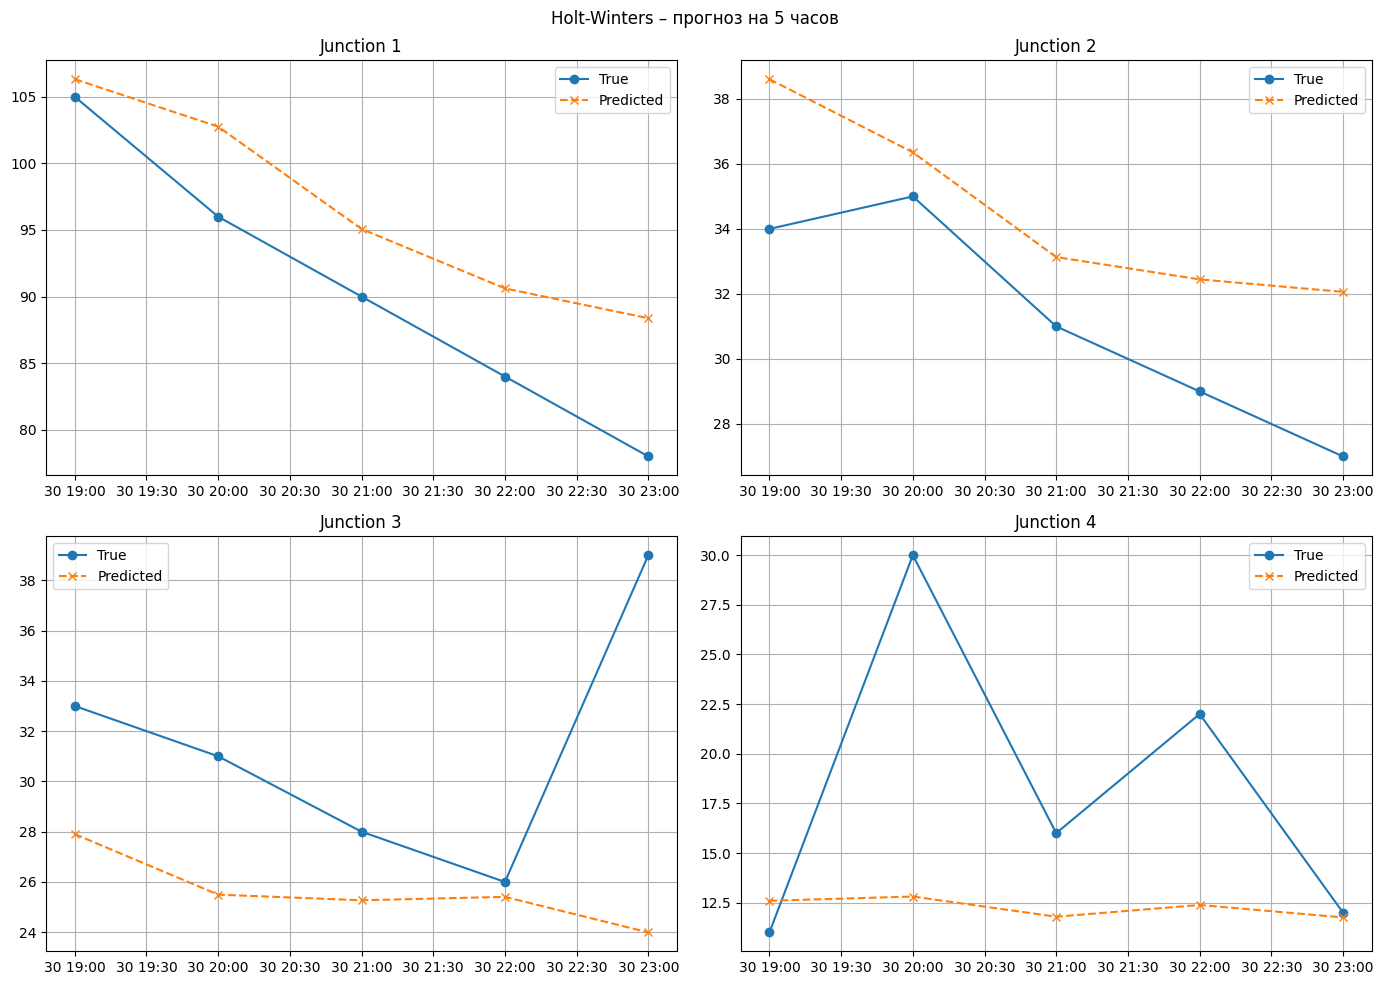

Holt-Winters: RMSE = 6.74, MSE = 49.37


In [54]:
#  визуализация и метрики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
rmse_list, mse_list = [], []

for i, j in enumerate(junctions):

    y_true = test_dfs[j]['y'].values
    y_pred = preds_hw[j]
    test_df = test_dfs[j]

    min_len = min(len(y_true), len(y_pred))
    y_true_trim = y_true[:min_len]
    y_pred_trim = y_pred[:min_len]

    mse = mean_squared_error(y_true_trim, y_pred_trim)
    rmse = np.sqrt(mse)
    mse_list.append(mse)
    rmse_list.append(rmse)

    ax = axes[i]
    dates = test_df['ds'].values[:min_len]
    ax.plot(dates, y_true_trim, label='True', marker='o')
    ax.plot(dates, y_pred_trim, '--', label='Predicted', marker='x')
    ax.set_title(f'Junction {j}')
    ax.legend()
    ax.grid(True)

plt.suptitle(f'Holt-Winters – прогноз на {horizon} часов')
plt.tight_layout()
plt.show()

print(f"Holt-Winters: RMSE = {np.mean(rmse_list):.2f}, MSE = {np.mean(mse_list):.2f}")

Проанализируем графики:

HoltWinters неплохо предсказал 1 и 3, средне 2 и очень плохо 4.

###4. AutoTheta

In [51]:
theta_model = AutoTheta(season_length=24)
preds_theta = {}
for j in junctions:
    sf = StatsForecast(models=[theta_model], freq='h')
    sf.fit(train_dfs[j])
    forecast = sf.predict(h=horizon)
    preds_theta[j] = forecast['AutoTheta'].values

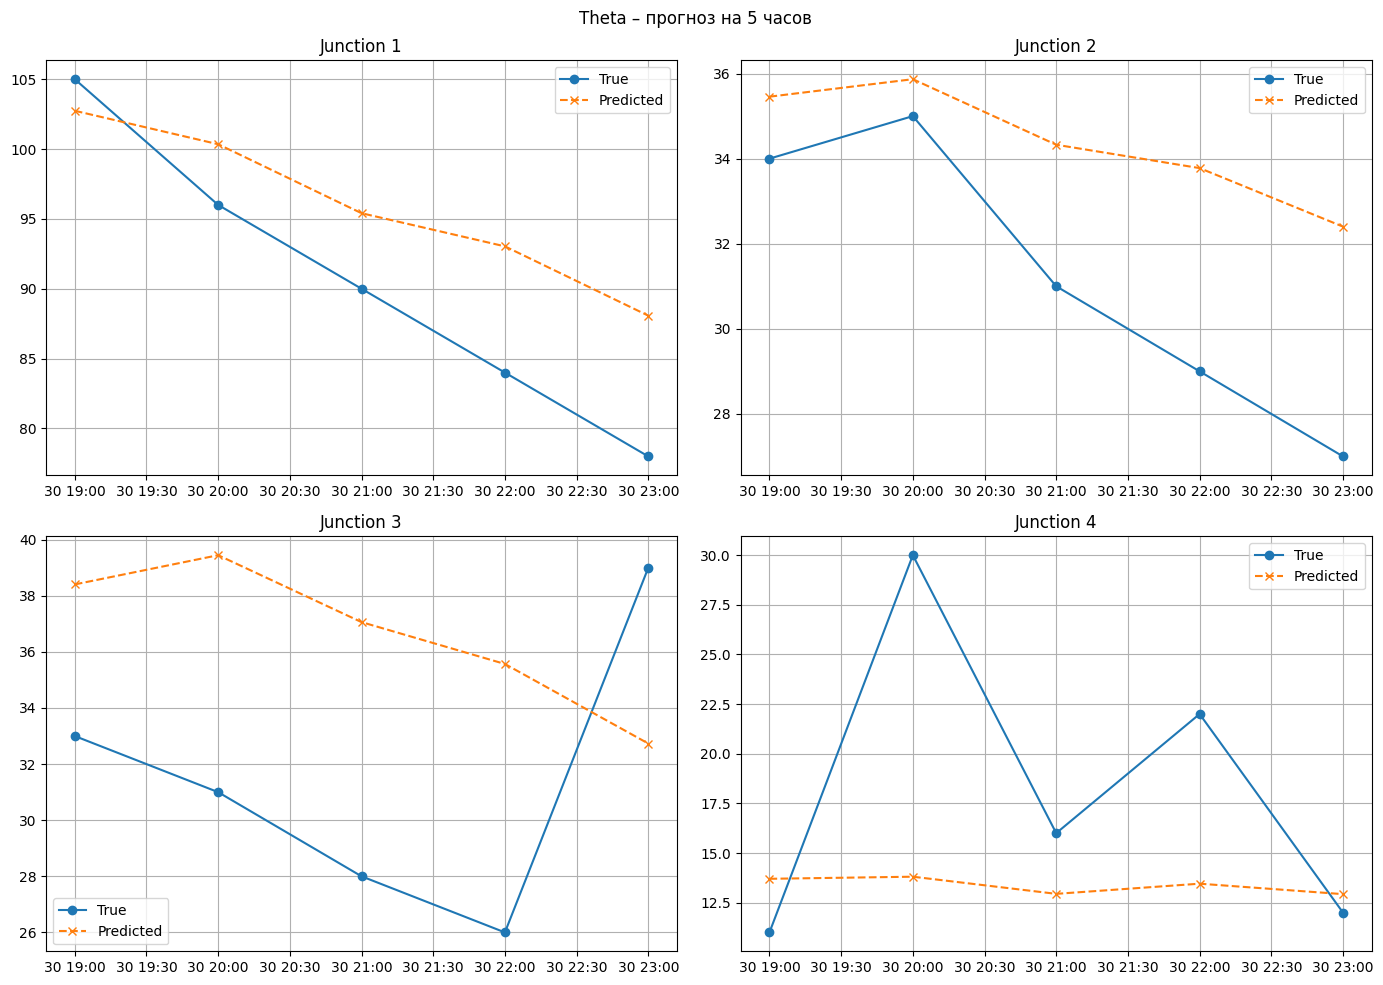

Theta: RMSE = 6.71, MSE = 48.43


In [52]:
# визуализация и метрики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
rmse_list, mse_list = [], []

for i, j in enumerate(junctions):
    y_true = test_dfs[j]['y'].values
    y_pred = preds_theta[j]

    min_len = min(len(y_true), len(y_pred))
    y_true_trim = y_true[:min_len]
    y_pred_trim = y_pred[:min_len]

    mse = mean_squared_error(y_true_trim, y_pred_trim)
    rmse = np.sqrt(mse)
    mse_list.append(mse)
    rmse_list.append(rmse)

    ax = axes[i]
    dates = test_df['ds'].values[:min_len]
    ax.plot(dates, y_true_trim, label='True', marker='o')
    ax.plot(dates, y_pred_trim, '--', label='Predicted', marker='x')
    ax.set_title(f'Junction {j}')
    ax.legend()
    ax.grid(True)

plt.suptitle(f'Theta – прогноз на {horizon} часов')
plt.tight_layout()
plt.show()
print(f"Theta: RMSE = {np.mean(rmse_list):.2f}, MSE = {np.mean(mse_list):.2f}")

Проанализируем графики:

theta более-менее предсказала 1-2 и очень плохо 3 и 4.

### Сравнение моделей по RMSE и MSE



In [72]:
all_predictions = {
    'Naive': results_naive['Naive'],
    'SeasonalNaive': results_naive['SeasonalNaive'],
    'ARIMA(1,1,1)': results_arima['ARIMA(1,1,1)'],
    'AutoARIMA': results_arima['AutoARIMA'],
    'ETS': preds_ets,
    'Holt-Winters': preds_hw,
    'Theta': preds_theta
}

results = []
for name, preds in all_predictions.items():
    rmse_vals, mse_vals = [], []
    for j in junctions:
        y_true = test_dfs[j]['y'].values
        y_pred = preds[j]
        mse = mean_squared_error(y_true[:len(y_pred)], y_pred)
        rmse = np.sqrt(mse)
        mse_vals.append(mse)
        rmse_vals.append(rmse)
    results.append({
        'Model': name,
        'RMSE': np.mean(rmse_vals),
        'MSE': np.mean(mse_vals)
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

        Model     RMSE       MSE
        Naive 7.398858 59.749999
SeasonalNaive 8.848987 84.550001
 ARIMA(1,1,1) 7.101583 56.724105
    AutoARIMA 7.015762 52.542931
          ETS 5.512975 40.229113
 Holt-Winters 6.738672 49.368735
        Theta 6.706290 48.428644


In [58]:
all_predictions = {
    'Naive': results_naive['Naive'],
    'SeasonalNaive': results_naive['SeasonalNaive'],
    'ARIMA(1,1,1)': results_arima['ARIMA(1,1,1)'],
    'AutoARIMA': results_arima['AutoARIMA'],
    'ETS': preds_ets,
    'Holt-Winters': preds_hw,
    'Theta': preds_theta
}

results = []
for name, preds in all_predictions.items():
    for j in junctions:
        y_true = test_dfs[j]['y'].values
        y_pred = preds[j]
        mse = mean_squared_error(y_true[:len(y_pred)], y_pred)
        rmse = np.sqrt(mse)
        results.append({
            'Model': name,
            'Junction': j,
            'RMSE': rmse,
            'MSE': mse
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

        Model  Junction      RMSE        MSE
        Naive         1 10.353743 107.199997
        Naive         2  4.098780  16.799999
        Naive         3  7.987490  63.799999
        Naive         4  7.155418  51.200001
SeasonalNaive         1 12.759310 162.800003
SeasonalNaive         2  5.796551  33.599998
SeasonalNaive         3  8.366600  70.000000
SeasonalNaive         4  8.473488  71.800003
 ARIMA(1,1,1)         1 10.777700 116.158813
 ARIMA(1,1,1)         2  3.737295  13.967377
 ARIMA(1,1,1)         3  6.567799  43.135979
 ARIMA(1,1,1)         4  7.323560  53.634533
    AutoARIMA         1  8.224515  67.642654
    AutoARIMA         2  3.934737  15.482153
    AutoARIMA         3  7.412662  54.947559
    AutoARIMA         4  8.491024  72.097481
          ETS         1  3.144895   9.890364
          ETS         2  1.756209   3.084269
          ETS         3  7.917027  62.679321
          ETS         4  9.233769  85.262497
 Holt-Winters         1  6.701850  44.914791
 Holt-Wint

###Выводы

Для выбранного ряда (трафик дорожного движения) ключевыми являются суточная и недельная сезонность. Также отмечено влияние выходных/праздников на трафик (снижение интенсивности).

- Наилучшую точность показала модель ETS (RMSE ≈ 5.51, MSE ≈ 40.23), что указывает на эффективность адаптивного экспоненциального сглаживания для данных с трендом и сезонностью.

- Методы Holt-Winters и Theta также дали хорошие результаты, немного уступая ETS.

- AutoARIMA и ARIMA(1,1,1) оказались сопоставимы, но менее точны, чем сезонные экспоненциальные модели.

- Наивные методы показали наибольшие ошибки, что подтверждает наличие выраженной сезонной структуры, которую простые подходы не учитывают.

Подытожим, данные хорошо предсказуемы с использованием методов, основанных на адаптивном экспоненциальном сглаживании. Для повышения точности требуется учёт дополнительных факторов и применение бектестинга и анализа остатков. Бектестинг нужен для оценки стабильности на разных периодах (например, будние и выходные), а анализ остатков позволяет выявить неучтённые паттерны (например, праздничные эффекты).

## ML и DL методы

In [25]:
# объединение датасетов в единые панельные DataFrame
train_panel = pd.concat(train_dfs.values(), ignore_index=True)
test_panel = pd.concat(test_dfs.values(), ignore_index=True)

In [26]:
# функция визуализации
def plot_predictions(y_true, y_pred_dict, model_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    for idx, uid in enumerate(y_true['unique_id'].unique()):
        ax = axes[idx]
        true_vals = y_true[y_true['unique_id'] == uid]
        ax.plot(true_vals['ds'], true_vals['y'], 'o-', label='True', color='black')
        for name, pred_df in y_pred_dict.items():
            pred_vals = pred_df[pred_df['unique_id'] == uid]
            ax.plot(pred_vals['ds'], pred_vals['y_hat'], 'o-', label=name)
        ax.set_title(uid)
        ax.legend()
        ax.grid(True)
    plt.suptitle(f'Прогноз {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [27]:
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

###Mlforecast: RandomForest, XGBoost и LightGBM

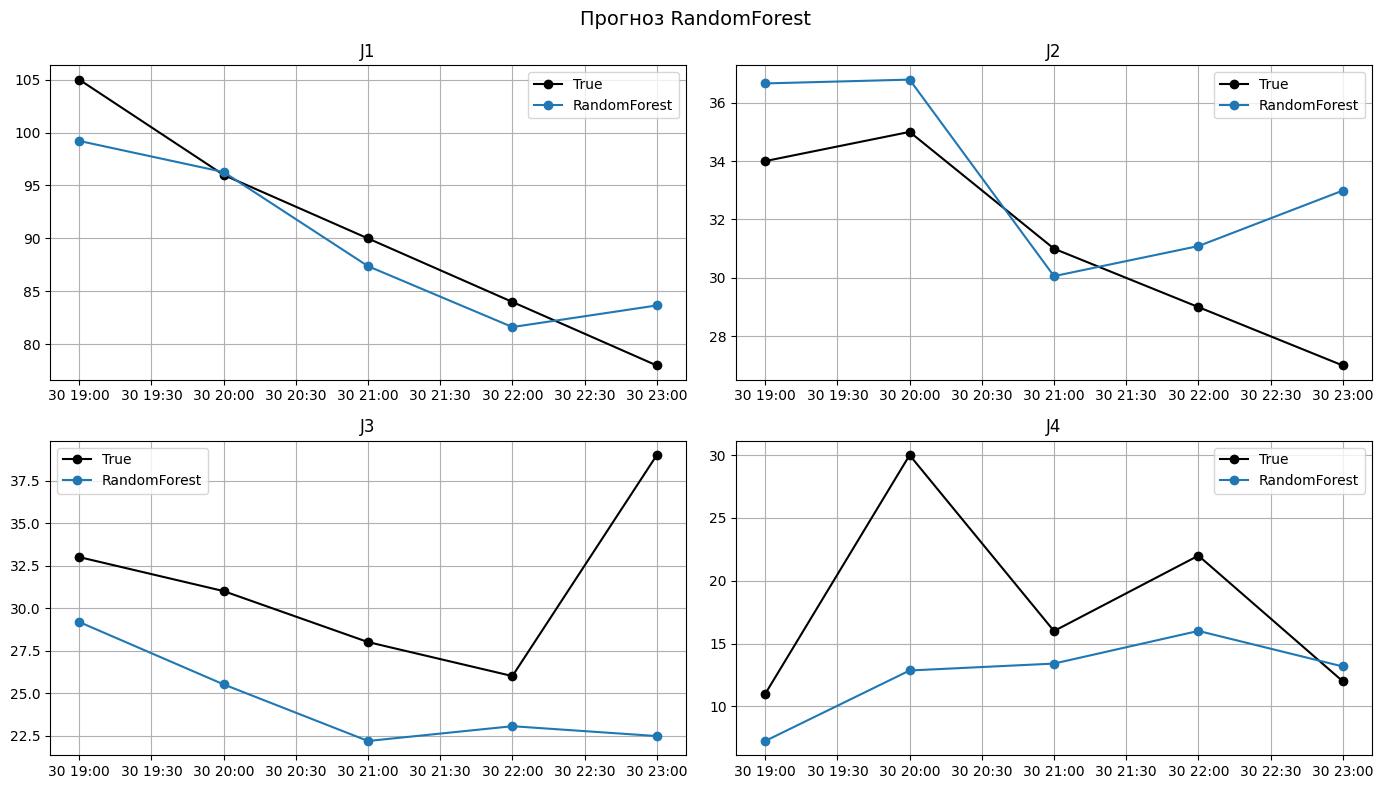

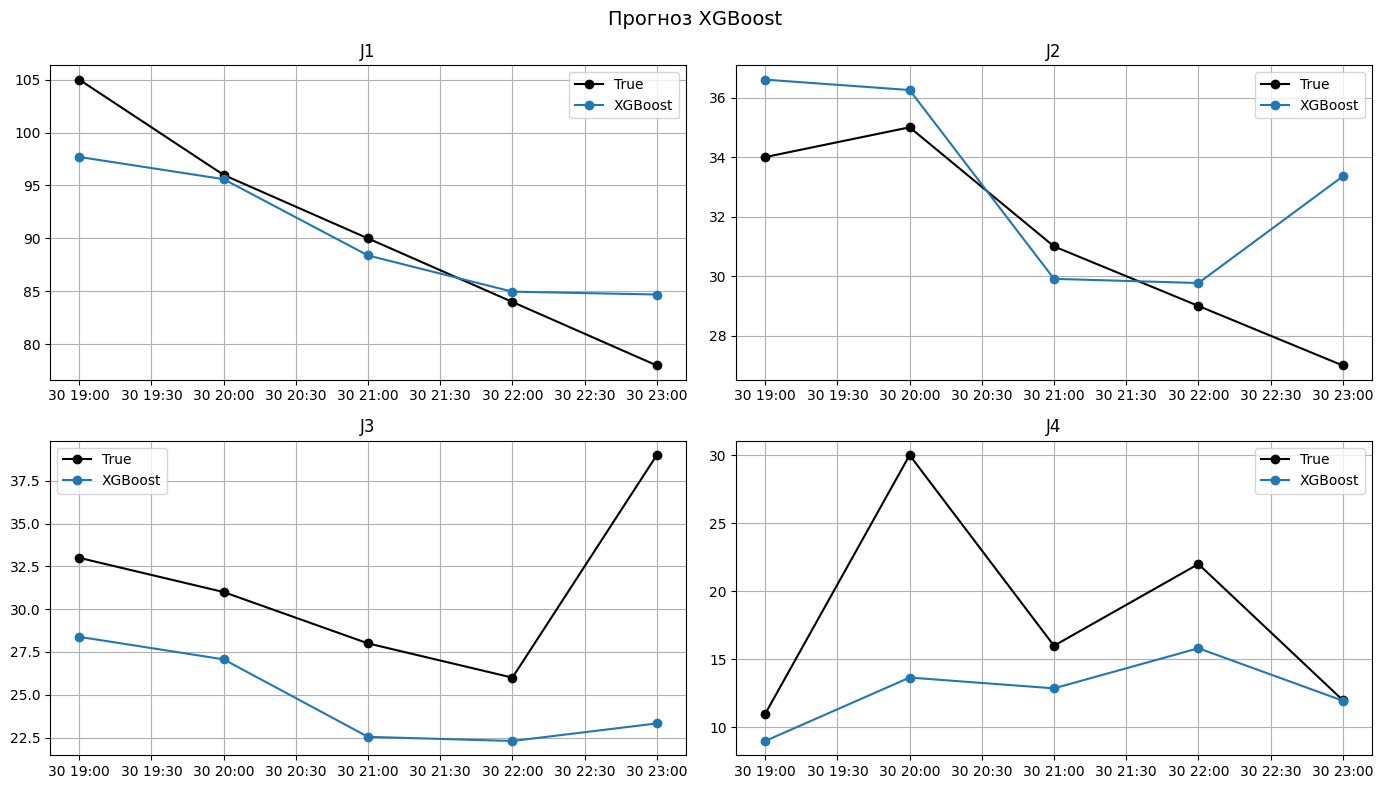

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 734
[LightGBM] [Info] Number of data points in the train set: 47332, number of used features: 8
[LightGBM] [Info] Start training from score 0.055671


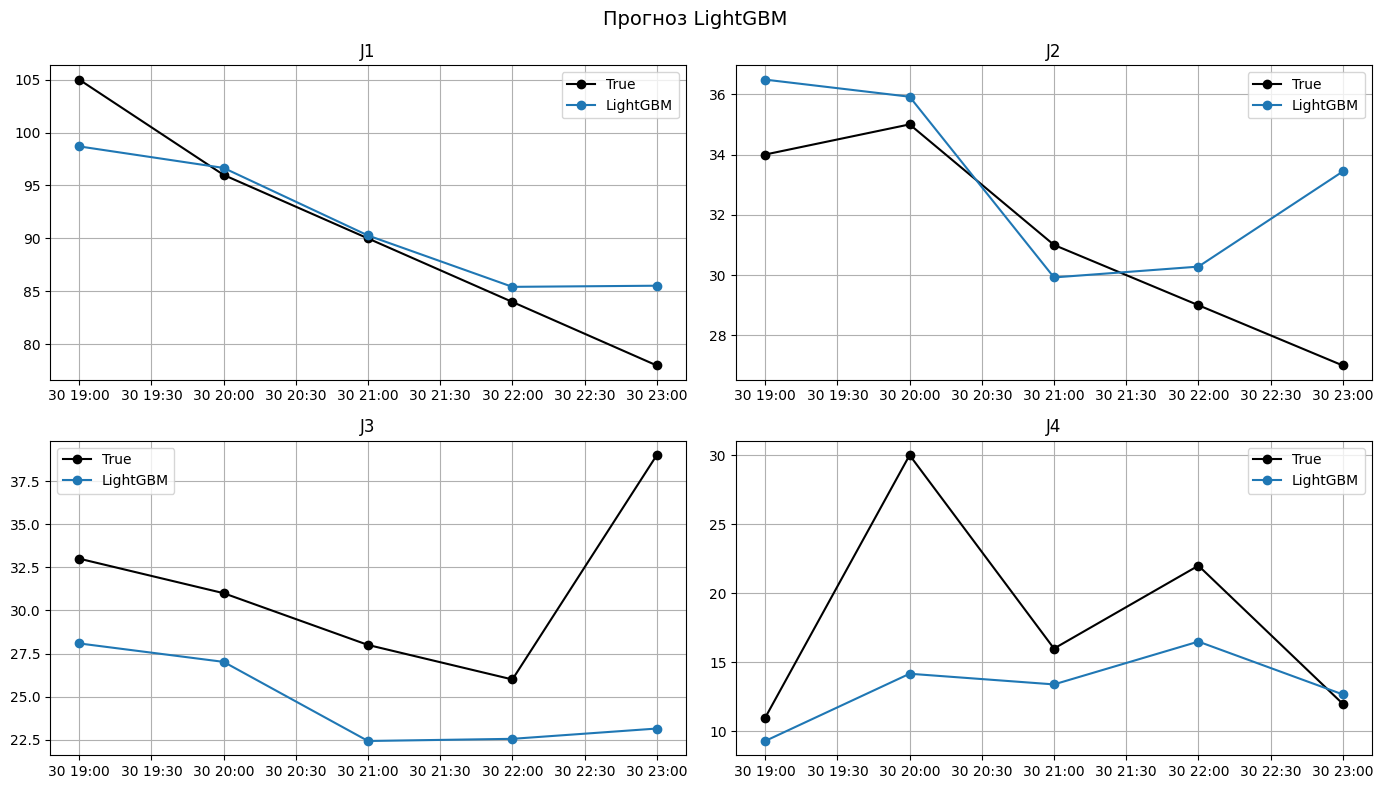

In [42]:
# параметры признаков
lags = [1, 2, 3, 24, 168]          # 1, 2, 3 часа, сутки, неделя
date_features = ['hour', 'dayofweek', 'month']

models_ml = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.05, max_depth=6, reg_alpha=0.1, reg_lambda=1.0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
}

ml_forecasts = {}

for name, model in models_ml.items():
    fcst = MLForecast(
    models={name: model},
    freq='H',
    lags=lags,
    date_features=date_features,
    target_transforms=[Differences([24])]
)
    fcst.fit(train_panel)
    preds = fcst.predict(h=horizon)
    preds = preds.rename(columns={name: 'y_hat'})
    ml_forecasts[name] = preds
    plot_predictions(test_panel, {name: preds}, name)

На графиках мы видим, что


*   RandomForest почти идеально предсказал первый перекресток, средне 2 и 4, совсем плохо 3 (на 3 часе сильное расхождение).
*   XGBoost почти идеально предсказал первый перекресток, средне 3 и 4, плохо 2.
*   LightGBM почти идеально предсказал первый перекресток, средне 2, плохо 3 и 4.

Можно отметить, что модели лучше предсказывают первые 4 лага, потом значение целевой переменной сильно расходиться. Значит мы можем эффективно прогнозировать на 4 часа.

### Neural forecast: NHITS,

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


Модель NHITS


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.8 M  | train
--------------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.201    Total estimated model params s

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

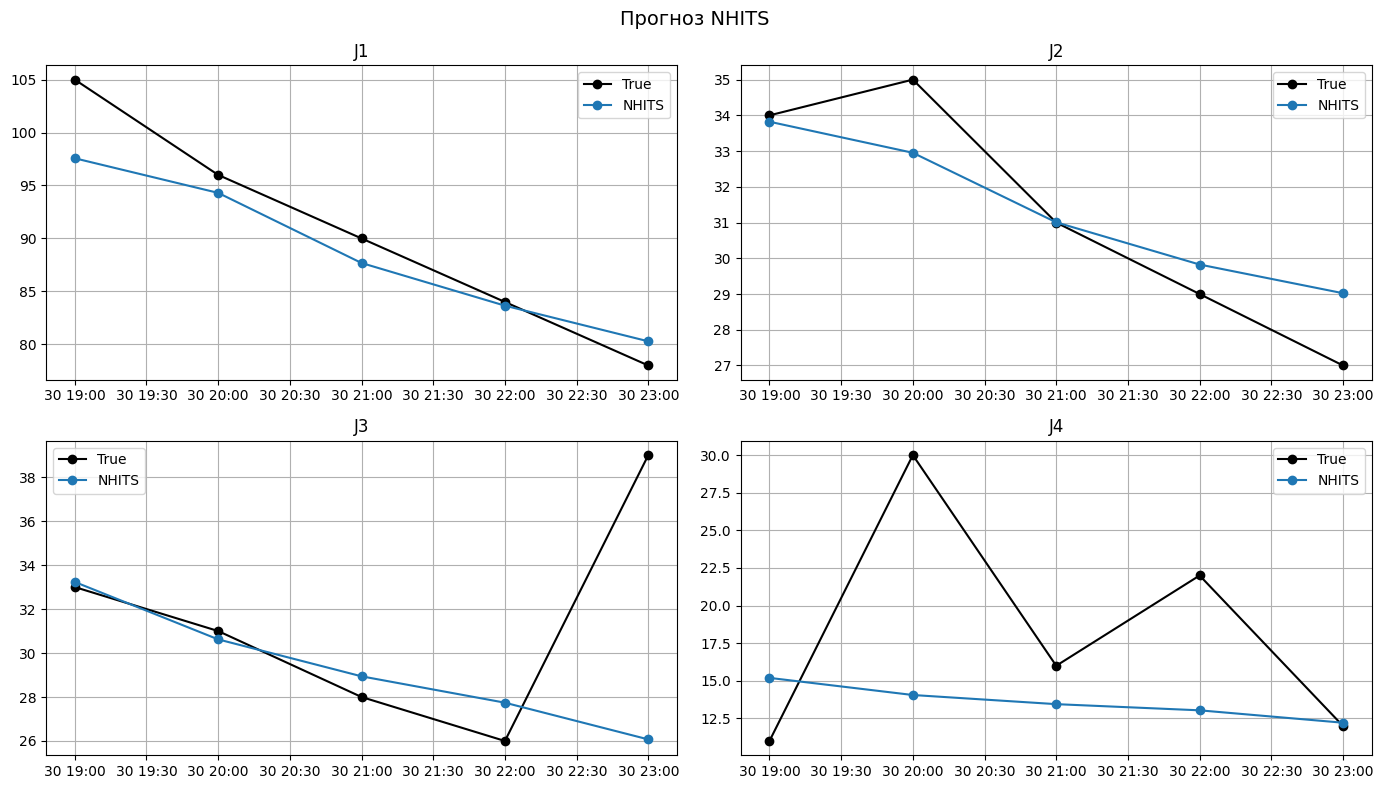

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.7 M  | train
--------------------------------------------------------------
2.7 M     Trainable params
1.9 K     Non-trainable params
2.7 M     Total params
10.902    Total estimated model params s

Модель NBEATS


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

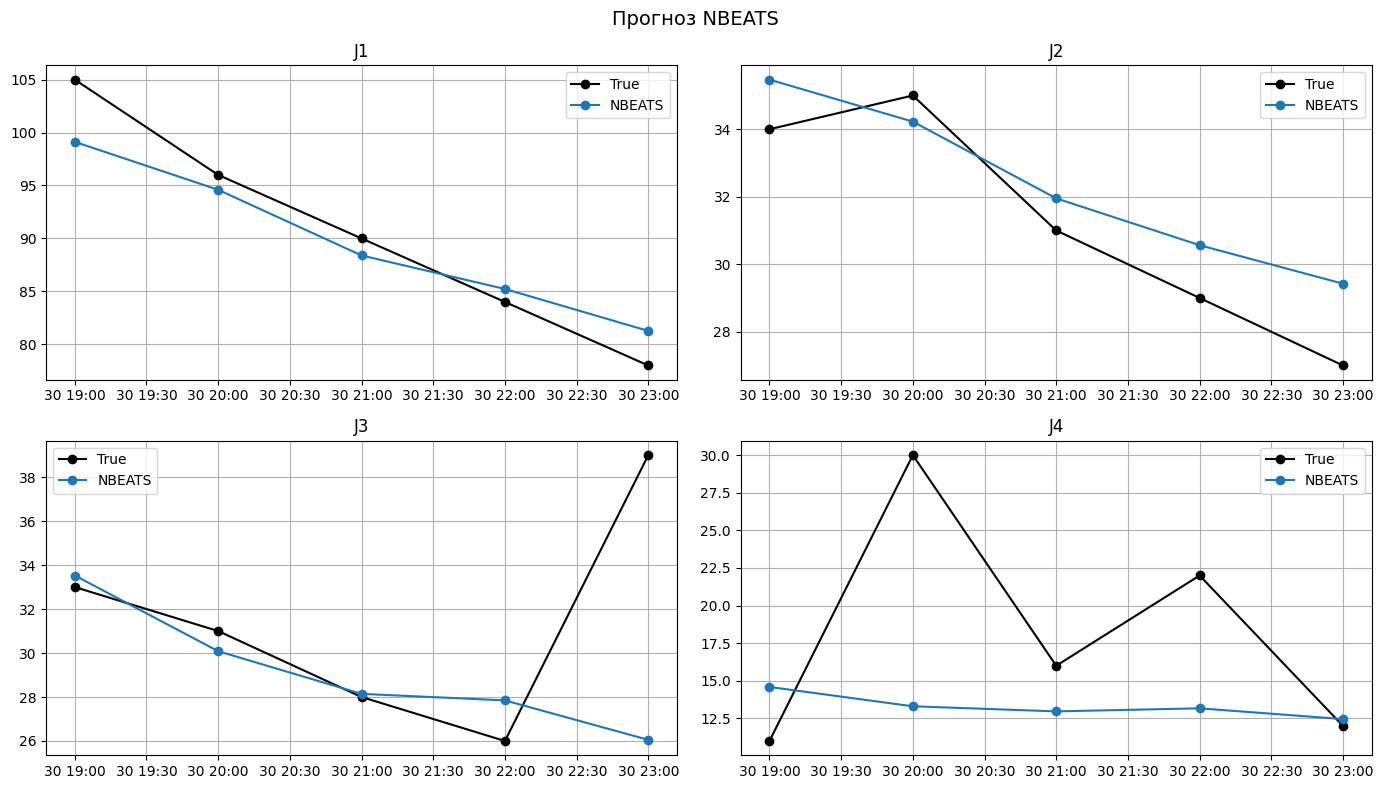

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Модель TFT


INFO:pytorch_lightning.callbacks.model_summary:
  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | hist_cat_embeddings     | ModuleList               | 0      | train
2 | futr_cat_embeddings     | ModuleList               | 0      | train
3 | stat_cat_embeddings     | ModuleList               | 0      | train
4 | padder_train            | ConstantPad1d            | 0      | train
5 | scaler                  | TemporalNorm             | 0      | train
6 | embedding               | TFTEmbedding             | 512    | train
7 | temporal_encoder        | TemporalCovariateEncoder | 613 K  | train
8 | temporal_fusion_decoder | TemporalFusionDecoder    | 256 K  | train
9 | output_adapter          | Linear                   | 129    | train
-----------------------------------------------------------------------------
870 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

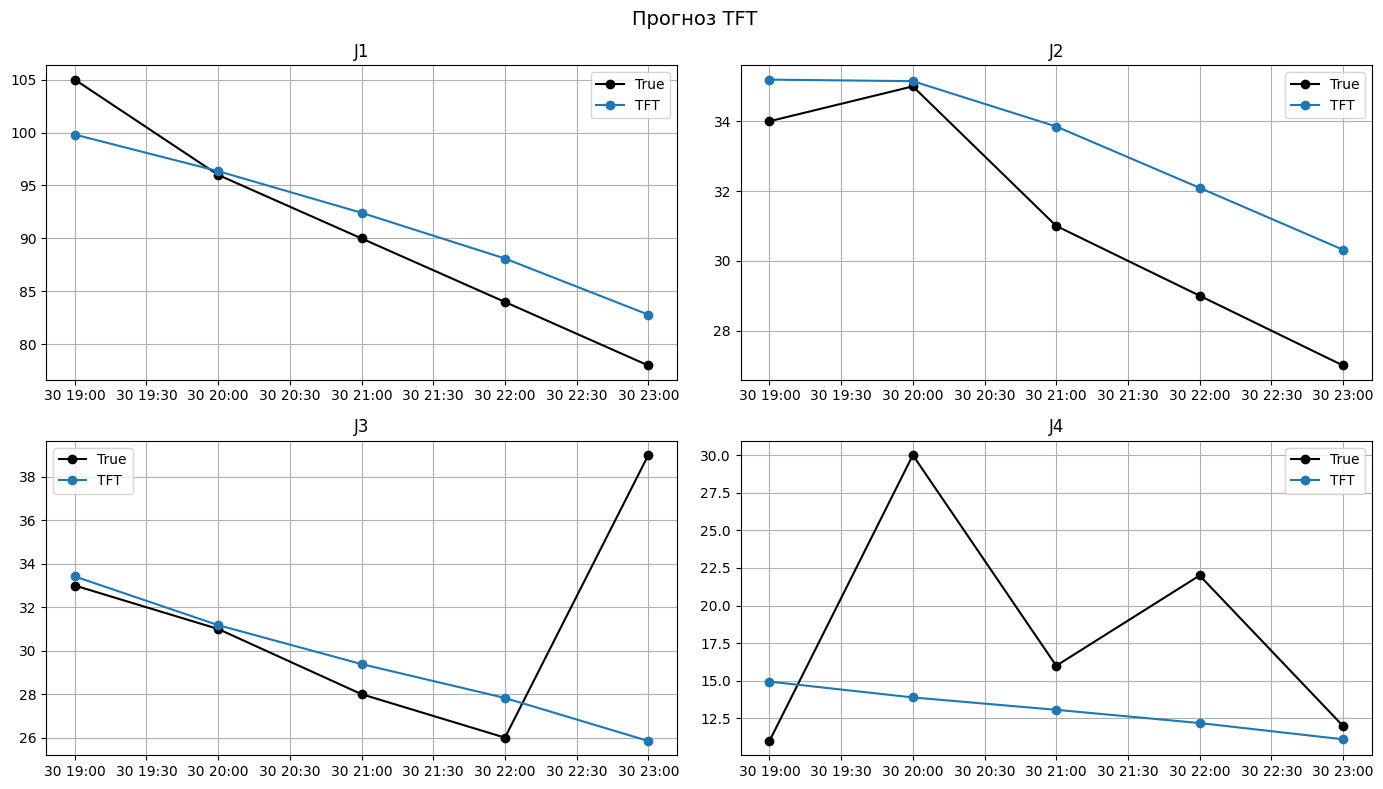

In [33]:
max_steps = 500

models_nf = {
    'NHITS': NHITS(h=horizon, input_size=168, max_steps=max_steps, loss=MAE()),
    'NBEATS': NBEATS(h=horizon, input_size=168, max_steps=max_steps, loss=MAE()),
    'TFT': TFT(h=horizon, input_size=168, max_steps=max_steps, loss=MAE())
    }

nf_forecasts = {}

for name, model in models_nf.items():
    print(f'Модель {name}')
    nf = NeuralForecast(
        models=[model],
        freq='H'
    )
    nf.fit(df=train_panel, val_size=horizon)
    preds = nf.predict()
    preds = preds.rename(columns={name: 'y_hat'})
    nf_forecasts[name] = preds
    plot_predictions(test_panel, {name: preds}, name)

На графиках мы видим, что

*   NHITS почти идеально предсказал 1 и 2 перекресток и первые 4 лага 3 перекрестка. По какой-то причине 4 перекресток предсказан очень плохо.
*   NBEATS - ситуация аналогична NHITS.
*   TFT почти идеально предсказал 1 и первые 4 лага перекрестка 3, нормально 1 лаг 2 перекрестка, а последующие для 2 предсказаны плохо, 4 перекресток предсказан очень плохо.

Суммируя выше сказанное,все модели очень хорошо предсказывают 1 перекресток, хорошо 2 и 3, совсем плохо 4.

Возможные причины, почему модели предсказывают не очень хорошо: 1. Нужно лучше подобрать параметры, 2. У четвертого перекрестка ряд стационарен и нет тренда. Возможно ошибки для 3 и 4 перекрестка связаны с тем, что в в 23 часа для 3 и в 20 и 22 для 4 динамика трафика меняется. Проверив еще несколько параметров МЛ моделей видны сильные изменения в предсказаниях перекрестков => для разных перекрестков нужны разные настройки для моделей.

1 и 2, 4 - Без регуляризации
3 - С регуляризацией (max_depth=6, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8)







###Сравнение моделей

In [59]:
def compute_metrics(y_true, y_pred, model_name):
    results = []
    for uid in y_true['unique_id'].unique():
        true_vals = y_true[y_true['unique_id'] == uid]['y'].values
        pred_vals = y_pred[y_pred['unique_id'] == uid]['y_hat'].values
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        mse = mean_squared_error(true_vals, pred_vals)
        results.append({
            'Model': model_name,
            'Junction': uid,
            'RMSE': rmse,
            'MSE': mse
        })
    return pd.DataFrame(results)

all_metrics = []
for name, preds in ml_forecasts.items():
    all_metrics.append(compute_metrics(test_panel, preds, name))
for name, preds in nf_forecasts.items():
    all_metrics.append(compute_metrics(test_panel, preds, name))

metrics_df = pd.concat(all_metrics, ignore_index=True)

pivot_rmse = metrics_df.pivot(index='Junction', columns='Model', values='RMSE')
pivot_mse = metrics_df.pivot(index='Junction', columns='Model', values='MSE')

print('\n=== Сравнение RMSE по перекрёсткам и моделям ===')
print(pivot_rmse.round(3))
print('\n=== Сравнение MSE по перекрёсткам и моделям ===')
print(pivot_mse.round(3))


=== Сравнение RMSE по перекрёсткам и моделям ===
Model     LightGBM  NBEATS  NHITS  RandomForest    TFT  XGBoost
Junction                                                       
J1           4.452   3.201  3.709         3.955  3.816    4.516
J2           3.202   1.548  1.341         3.207  2.455    3.177
J3           8.171   5.869  5.852         8.492  5.975    8.075
J4           7.623   8.706  8.470         8.388  8.724    7.986

=== Сравнение MSE по перекрёсткам и моделям ===
Model     LightGBM  NBEATS   NHITS  RandomForest     TFT  XGBoost
Junction                                                         
J1          19.818  10.249  13.755        15.645  14.562   20.398
J2          10.253   2.397   1.799        10.282   6.026   10.094
J3          66.766  34.441  34.250        72.110  35.695   65.204
J4          58.114  75.790  71.736        70.365  76.105   63.781


1. Нейросети (NBEATS, NHITS, TFT) лучше работают на 1 и 3, особенно на 2 и 3, где их RMSE в 2–2.5 раза ниже, чем у деревьев. Для рядов с чёткой сезонностью и трендом специализированные архитектуры работают лучше.

2. Для 4 перекрестка LightGBM и XGBoost делают прогнозы лучше, чем нейросети.Возможно, данные более шумные или имеют менее выраженные паттерны, где нейросети переобучаются, а деревья с регуляризацией оказываются более устойчивыми.

----------------------

Лучшие модели для каждого перекрёстка:

1 - LightGBM - RMSE 4.452 - MSE 19.818

2 -	NHITS	- RMSE  1.341	-	MSE 1.799

3 -	XGBoost	- RMSE 8.075 - MSE 65.204

4 - LightGBM - RMSE	7.623	-	MSE 58.114

## Резюме: Лучшие модели для прогнозирования трафика на перекрестках

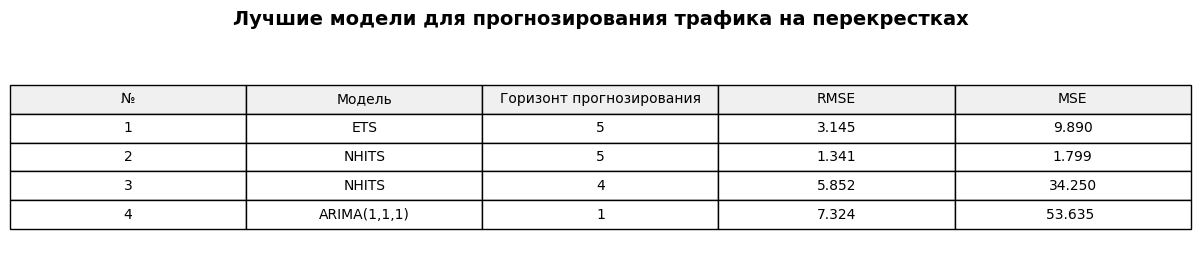

In [64]:
data = [
    ["1", "ETS", 5, "3.145", "9.890"],
    ["2", "NHITS", 5, "1.341", "1.799"],
    ["3", "NHITS", 4, "5.852", "34.250"],
    ["4", "ARIMA(1,1,1)", 1, "7.324", "53.635 "]
]

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

table = ax.table(
    cellText=data,
    colLabels=["№", "Модель", "Горизонт прогнозирования", "RMSE", "MSE"],
    loc='center',
    cellLoc='center',
    colColours=['#f0f0f0'] * 6
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.suptitle(
    "Лучшие модели для прогнозирования трафика на перекрестках",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()